In [1]:
#podstawowe biblioteki
import os #do obsługi katalogów
from joblib import dump, load #do zapisywania i wczytywania danych (żeby nie liczyć od nowa)

from tqdm.notebook import tqdm #do wyświetlania pasków postępu przy obliczeniach

#!jupyter nbextension enable --py widgetsnbextension #włączanie pasków gdyby nie działały

#obliczenia
import numpy as np
import pandas as pd

#generowanie list plików
import glob

#wyrażenia regularne
import re

# wykresy
#import pyLDAvis
import matplotlib.pyplot as plt
%matplotlib inline

#obsługa komunikatów o błędach itp.
import logging

#lematyzacja
import spacy

#topic modelling
import gensim.corpora as corpora
import gensim.models.callbacks
from gensim.models import CoherenceModel
from gensim.utils import simple_preprocess

In [2]:
#WCZYTYWANIE, PRZYGOTOWYWANIE TEKSTÓW

In [2]:
filenames=glob.glob("A_Small_Collection_of_British_Fiction-master/corpus/*.txt")

In [3]:
data=[] #surowe teksty
labels=[] #tytuły + autorzy z nazwy pliku

for filename in filenames:
    labels.append(filename.split('\\')[-1])
    with open(filename, newline='\n', encoding='utf-8-sig') as file: text=file.read()
    data.append(text)

In [5]:
dump(labels, "labels_warsztaty.joblib")

['labels_warsztaty.joblib']

In [6]:
data=[re.sub('\r\n', ' ', text) for text in data]

In [21]:
#model do lematyzacji
nlp = spacy.load('en_core_web_sm', disable = ['parser','ner'])

#jeżeli to możliwe - liczyć na GPU
spacy.prefer_gpu()

#maksymalna długość tekstu
nlp.max_length=6000000

#wczytywanie listy słów do pominięcia
with open('stoplist_eng.txt', newline='\n', encoding='utf8') as file: raw_stopwords=file.read()
temp_stopwords=raw_stopwords.split('\n')
stop_words=[]
for word in temp_stopwords:
    stop_words.append(word.lower())

In [22]:
counter=0
data_lemmatized=[]
for text in data:
    doc = nlp(text)
    text_lemmatized=[]
    for token in doc:
        if token.lemma_ not in stop_words:
            if len(token.lemma_)>1:
                if(token.lemma_.isalpha()):
                    text_lemmatized.append(token.lemma_)
    data_lemmatized.append(text_lemmatized)
    print(counter)
    counter=counter+1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26


In [23]:
data_lemmatized[1]

['Tenant',
 'Wildfell',
 'Hall',
 'AUTHOR',
 'PREFACE',
 'second',
 'EDITION',
 'acknowledge',
 'success',
 'present',
 'work',
 'anticipate',
 'praise',
 'elicit',
 'kind',
 'critic',
 'deserve',
 'admit',
 'quarter',
 'censure',
 'asperity',
 'little',
 'prepared',
 'expect',
 'judgment',
 'feeling',
 'assure',
 'bitter',
 'scarcely',
 'province',
 'author',
 'refute',
 'argument',
 'censor',
 'vindicate',
 'production',
 'allow',
 'observation',
 'preface',
 'edition',
 'foresee',
 'necessity',
 'precaution',
 'misapprehension',
 'read',
 'prejudiced',
 'mind',
 'content',
 'judge',
 'hasty',
 'glance',
 'object',
 'write',
 'follow',
 'simply',
 'amuse',
 'Reader',
 'gratify',
 'taste',
 'ingratiate',
 'Press',
 'public',
 'wish',
 'truth',
 'truth',
 'convey',
 'moral',
 'able',
 'receive',
 'priceless',
 'treasure',
 'frequently',
 'hide',
 'bottom',
 'need',
 'courage',
 'dive',
 'especially',
 'incur',
 'scorn',
 'obloquy',
 'mud',
 'water',
 'venture',
 'plunge',
 'thank',
 'p

In [24]:
dump(data_lemmatized, 'data_lemmatized_warsztaty.joblib')

['data_lemmatized_warsztaty.joblib']

In [95]:
#data_lemmatized=load('data_lemmatized_warsztaty.joblib')

In [25]:
#tworzenie "słownika" w formacie gensimowym

id2word = corpora.Dictionary(data_lemmatized)

In [26]:
dump(id2word, 'id2word_warsztaty.joblib')

['id2word_warsztaty.joblib']

In [27]:
#tworzenie korpusu w formacie używanym przez gensim do trenowania modelu

texts_chunked=[]

def divide_chunks(l, n): 
      
    # looping till length l 
    for i in range(0, len(l), n):  
        yield l[i:i + n] 

# How many elements each list should have 

n = 100

for text in data_lemmatized:
    chunks=list(divide_chunks(text, n))
    for chunk in chunks:
        texts_chunked.append(chunk)

In [28]:
# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts_chunked]

In [29]:
dump(corpus, "corpus_warsztaty.joblib")

['corpus_warsztaty.joblib']

In [101]:
#TRENOWANIE

In [4]:
#poniższe linie po odkomentowaniu (usunięciu "#") wczytują wygenerowane wcześniej pliki (zapisane przy użyciu polecenia "dump")
data_lemmatized=load('data_lemmatized_warsztaty.joblib')
id2word=load('id2word_warsztaty.joblib')
corpus=load('corpus_warsztaty.joblib')
labels=load('labels_warsztaty.joblib')

In [5]:
#trenowanie modelu na podstawie przygotowanych danych
#parametry dostosowane do korpusu młodopolskiego

lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=31,
                                            random_state=100,
                                           update_every=1,
                                           #chunksize=100,
                                           passes=6,
                                           iterations=100,
                                           alpha=0.7,
                                           eta=0.3, # beta in sklearn
                                           per_word_topics=True)

In [31]:
dump(lda_model, 'model_warsztaty_31t_6p_100i.joblib')

['model_warsztaty_31t_6p_100i.joblib']

In [7]:
lda_model=load('model_warsztaty_31t_6p_100i.joblib')

In [ ]:
#sprawdzanie koherencji modelu (spójności semantycznej)

In [64]:
coherence_model_lda = CoherenceModel(model=lda_model, texts=data_lemmatized, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
coherence_lda

np.float64(0.5871897229115823)

In [ ]:
#wyświetlanie zawartości słowozbiorów

In [6]:
topics=lda_model.print_topics()
#topics.sort()
topics

[(np.int64(23),
  '0.082*"letter" + 0.036*"write" + 0.021*"Miss" + 0.018*"LETTER" + 0.015*"Lovelace" + 0.015*"Howe" + 0.015*"CHAPTER" + 0.013*"Colonel" + 0.009*"HARLOWE" + 0.008*"send"'),
 (np.int64(1),
  '0.015*"heart" + 0.012*"life" + 0.009*"word" + 0.009*"feel" + 0.008*"hand" + 0.008*"mind" + 0.008*"speak" + 0.007*"God" + 0.007*"look" + 0.006*"leave"'),
 (np.int64(17),
  '0.002*"Sleary" + 0.001*"Thquire" + 0.001*"omnibus" + 0.001*"ith" + 0.001*"sive" + 0.001*"wath" + 0.001*"Gradgrind" + 0.000*"Maledictus" + 0.000*"ath" + 0.000*"Sissy"'),
 (np.int64(9),
  '0.000*"unworldly" + 0.000*"Junction" + 0.000*"Tenway" + 0.000*"Aga" + 0.000*"Kislar" + 0.000*"telegram" + 0.000*"Pen" + 0.000*"Glenmalony" + 0.000*"Magenis" + 0.000*"Hammerdown"'),
 (np.int64(15),
  '0.035*"Eleanor" + 0.026*"Arabin" + 0.022*"Thorne" + 0.021*"Bold" + 0.015*"folk" + 0.014*"Bertie" + 0.013*"Stanhope" + 0.011*"signora" + 0.011*"captain" + 0.008*"Slope"'),
 (np.int64(19),
  '0.024*"Francis" + 0.004*"brag" + 0.002*"strai

In [8]:
#najczęstsze słowozbiory w poszczególnych tekstach

topicscores=[]

for text in data_lemmatized:
    doc_vectorized=id2word.doc2bow(text)
    topic_probability_scores = lda_model.get_document_topics(doc_vectorized, minimum_probability=0)    
    #scores=[]
    #for element in topic_probability_scores:
    #    scores.append(element[1])
    topicscores.append(topic_probability_scores)

In [9]:
topicscores_sorted=[]

for scores in topicscores:
    topicscores_sorted.append(sorted(scores, key=lambda x: x[1], reverse=True))

In [10]:
topicscores_texts=[]

for bookno in range(len(labels)):
    #print(labels[bookno], topicscores_sorted[bookno][0][0])
    currentbook=[]
    currentbook.append(labels[bookno])
    currentbook.append(topicscores_sorted[bookno][0][0])
    currentbook.append(topicscores_sorted[bookno][1][0])
    currentbook.append(topicscores_sorted[bookno][2][0])
    topicscores_texts.append(currentbook)

In [11]:
topicscores_texts

[['ABronte_Agnes.txt', 30, 14, 1],
 ['ABronte_Tenant.txt', 1, 30, 26],
 ['Austen_Emma.txt', 30, 14, 28],
 ['Austen_Pride.txt', 30, 28, 14],
 ['Austen_Sense.txt', 30, 1, 7],
 ['CBronte_Jane.txt', 26, 1, 14],
 ['CBronte_Professor.txt', 26, 1, 28],
 ['CBronte_Villette.txt', 26, 1, 28],
 ['Dickens_Bleak.txt', 14, 26, 30],
 ['Dickens_David.txt', 14, 26, 1],
 ['Dickens_Hard.txt', 26, 14, 1],
 ['EBronte_Wuthering.txt', 18, 26, 1],
 ['Eliot_Adam.txt', 26, 1, 14],
 ['Eliot_Middlemarch.txt', 1, 29, 26],
 ['Eliot_Mill.txt', 1, 14, 26],
 ['Fielding_Joseph.txt', 25, 30, 18],
 ['Fielding_Tom.txt', 25, 30, 18],
 ['Richardson_Clarissa.txt', 30, 1, 23],
 ['Richardson_Pamela.txt', 30, 14, 1],
 ['Sterne_Sentimental.txt', 26, 6, 1],
 ['Sterne_Tristram.txt', 11, 25, 30],
 ['Thackeray_Barry.txt', 25, 14, 28],
 ['Thackeray_Pendennis.txt', 14, 28, 26],
 ['Thackeray_Vanity.txt', 14, 28, 26],
 ['Trollope_Barchester.txt', 25, 1, 14],
 ['Trollope_Phineas.txt', 29, 30, 13],
 ['Trollope_Prime.txt', 29, 30, 1]]

In [ ]:
#prawdopodobieństwa w kolejnych częściach jednego tekstu - definiowanie funkcji

In [12]:
def rolling_topic_gensim(text, no_topic, steps):
    results=[]
    chunks=[]
    
    no_steps=steps
    step=int(len(text)/no_steps)
    window_size=int(len(text)/(no_steps-1))

    for counter in range(no_steps):
        chunk=[]
        chunk=text[counter*step:(counter*step+window_size)]
        chunks.append(chunk)
        chunk_vectorized = id2word.doc2bow(chunk)
        topic_probability_scores = lda_model.get_document_topics(chunk_vectorized, minimum_probability=0)
        results.append(topic_probability_scores[no_topic][1]) # <-- topic number to check, defined above
        #print(counter, '/', no_steps)
        #clear_output()
    return results#, chunks

In [14]:
#tworzenie list wyrazów ze słowozbiorów do dalszego wykorzystania

keyw=lda_model.show_topics(num_topics=31, num_words=5, formatted=True)
keyw.sort()
keyw

[(0,
  '0.010*"Elizabeth" + 0.007*"Bingley" + 0.004*"Darcy" + 0.003*"Peggy" + 0.003*"Bennet"'),
 (1,
  '0.015*"heart" + 0.012*"life" + 0.009*"word" + 0.009*"feel" + 0.008*"hand"'),
 (2,
  '0.147*"sir" + 0.008*"Bounderby" + 0.005*"Leicester" + 0.005*"lawyer" + 0.005*"gentleman"'),
 (3,
  '0.005*"Honner" + 0.004*"snub" + 0.002*"deer" + 0.001*"younge" + 0.001*"plane"'),
 (4,
  '0.002*"breaking" + 0.001*"crutch" + 0.001*"traditional" + 0.000*"Junction" + 0.000*"Tenway"'),
 (5,
  '0.002*"disgusted" + 0.001*"balk" + 0.001*"drawl" + 0.001*"prophet" + 0.001*"intricate"'),
 (6,
  '0.056*"Madame" + 0.037*"de" + 0.011*"Monsieur" + 0.007*"la" + 0.006*"Paris"'),
 (7,
  '0.041*"horse" + 0.028*"ride" + 0.016*"coach" + 0.012*"day" + 0.012*"Doctor"'),
 (8,
  '0.038*"Duke" + 0.035*"Sir" + 0.026*"Crawley" + 0.017*"Duchess" + 0.016*"old"'),
 (9,
  '0.000*"unworldly" + 0.000*"Junction" + 0.000*"Tenway" + 0.000*"Aga" + 0.000*"Kislar"'),
 (10,
  '0.002*"Greenwich" + 0.002*"Badger" + 0.001*"kentish" + 0.001*"

In [15]:
topicwords=[]

for topic in range(len(keyw)):
    words=[]
    for word in keyw[topic][1].split('+'):
        words.append(re.search('"(.+?)"', word).group(1))
    topicwords.append(words)

In [43]:
from wordcloud import WordCloud

#generowanie chmury słów na podstawie listy frekwencyjnej
wordcloud = WordCloud (width=1600, height=800, background_color='white').generate(' '.join(topicwords[1]))

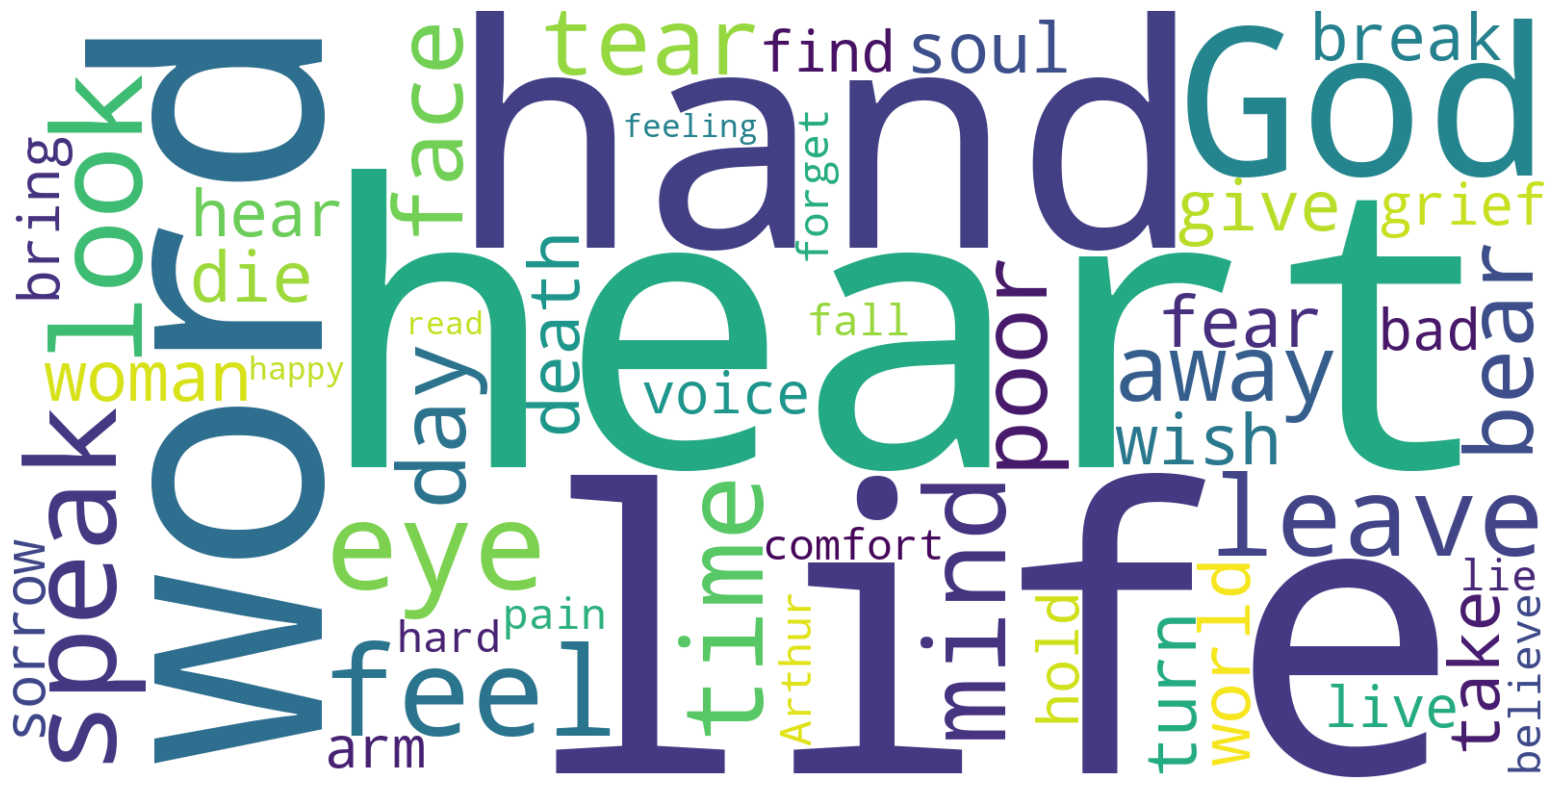

In [44]:
#umieszczanie danych na rysunku i wyświetlanie
plt.figure(figsize=(20, 10)) #szerokość i wysokość rysunku
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [16]:
wyniki=[]

for textno in (range(0, len(data_lemmatized))):
    rolling_topics=[]
    for topicno in range(0,len(keyw)):
        rolling_topics.append(rolling_topic_gensim(data_lemmatized[textno], topicno, 30))
    wyniki.append(rolling_topics)

In [17]:
dump(wyniki, 'wyniki_warsztaty_model_pl_31t_6p_100i.joblib')

['wyniki_warsztaty_model_pl_31t_6p_100i.joblib']

In [45]:
wyniki=load('wyniki_warsztaty_model_pl_31t_6p_100i.joblib')

In [18]:
#podsumowanie wyników w jednej tabeli do dalszych obliczeń

all_res=[]

for tekst in wyniki:
    for topic in tekst:
        for result in topic:
            all_res.append(result)

#max(all_res)

In [19]:
all_res[0]

np.float32(0.000936292)

In [20]:
topicsums=[]

for tekst in range(0,len(wyniki)):
    topics=[]
    for topic in range(0,20):
        topics.append(sum(wyniki[tekst][topic]))
    topicsums.append(topics)

In [21]:
topicsumsbase=[]

for tekst in topicsums:
    tekst_temp=[]
    for topic in range(len(tekst)):
        temp=[]
        temp.append(topic)
        temp.append(tekst[topic])
        tekst_temp.append(temp)
    topicsumsbase.append(tekst_temp)
    
topicsumsbase=np.array(topicsumsbase)

In [22]:
sorted(topicsumsbase[0],key=lambda x: x[1], reverse=True)

[array([14.        ,  5.17606497]),
 array([1.        , 5.13047314]),
 array([18.        ,  0.84006643]),
 array([7.        , 0.37301111]),
 array([15.        ,  0.23535398]),
 array([16.        ,  0.19118452]),
 array([13.        ,  0.14248568]),
 array([11.        ,  0.06813186]),
 array([2.        , 0.05875718]),
 array([8.        , 0.04962517]),
 array([12.       ,  0.0376876]),
 array([6.        , 0.03240394]),
 array([5.        , 0.03088449]),
 array([19.        ,  0.02969697]),
 array([3.        , 0.02884721]),
 array([9.        , 0.02849659]),
 array([4.       , 0.0284888]),
 array([17.        ,  0.02847154]),
 array([10.       ,  0.0284681]),
 array([0.        , 0.02838673])]

In [23]:
topicsumsbase_sorted=[]

for tekst in range(len(topicsumsbase)):
    topicsumsbase_sorted.append(sorted(topicsumsbase[tekst],key=lambda x: x[1], reverse=True))

In [24]:
len(topicsumsbase_sorted)

27

In [25]:
dom_topics=[]

for tekst in topicsumsbase_sorted:
    temp=[]
    for element in tekst[:5]:
        temp.append(int(element[0]))
    dom_topics.append(temp)

In [26]:
for counter in range(len(wyniki[0][5])):
    print(counter, wyniki[0][5][counter])

0 0.0009400639
1 0.0009371792
2 0.000943341
3 0.00096193294
4 0.0009348748
5 0.0009578029
6 0.0009767036
7 0.0009771013
8 0.0022498218
9 0.0009604938
10 0.000947479
11 0.00094608427
12 0.0010262129
13 0.00094760966
14 0.0020589125
15 0.0009611573
16 0.0009319238
17 0.0009660481
18 0.00093137263
19 0.000935743
20 0.00092984375
21 0.00095056253
22 0.0009327412
23 0.0009551341
24 0.0009142506
25 0.0009183607
26 0.00094089727
27 0.000970145
28 0.0009343926
29 0.00094629935


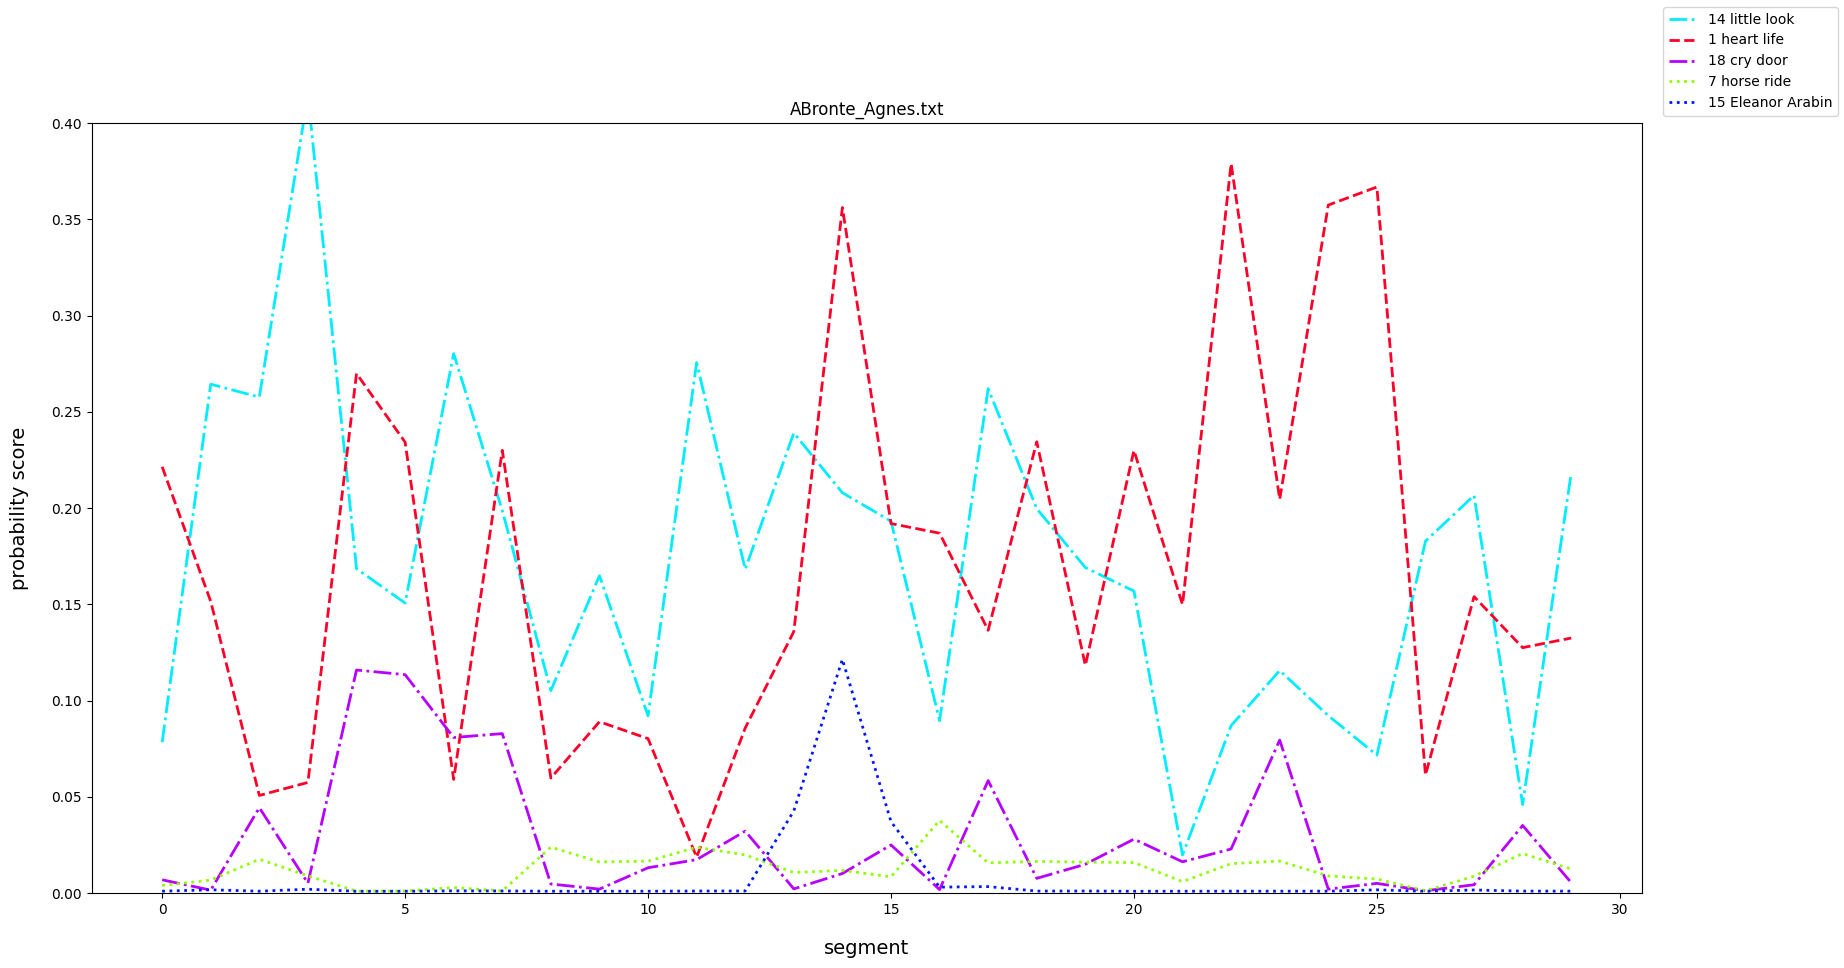

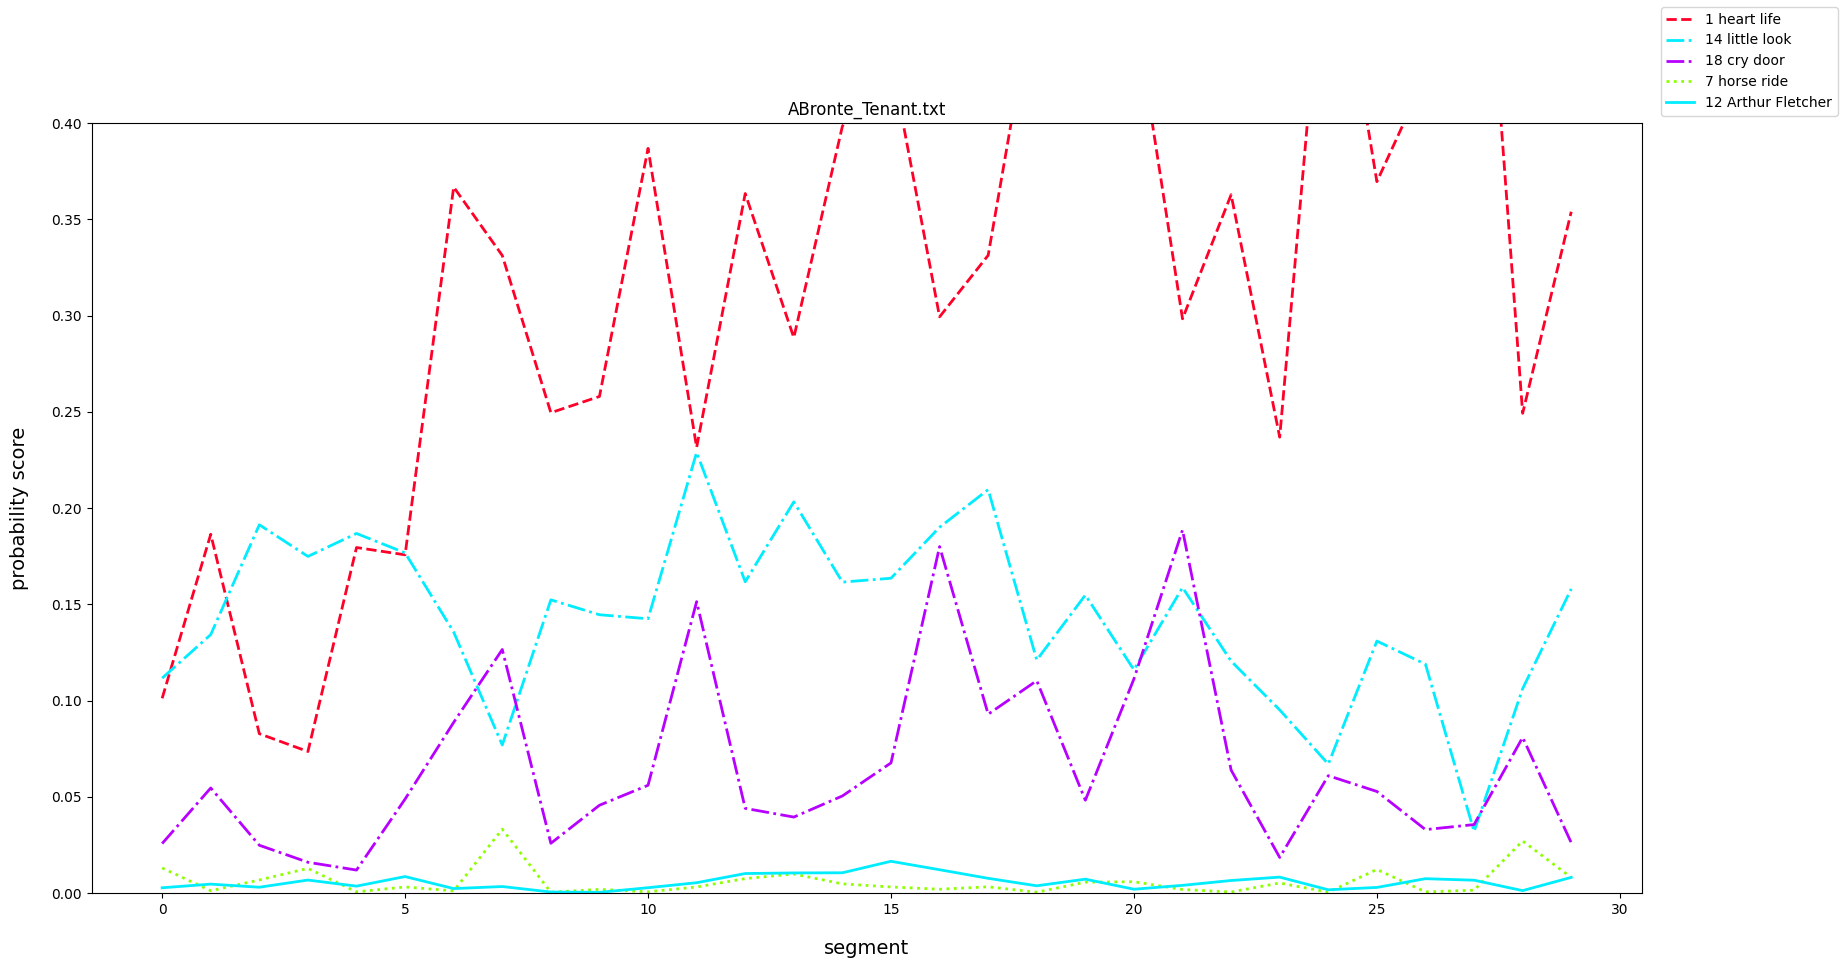

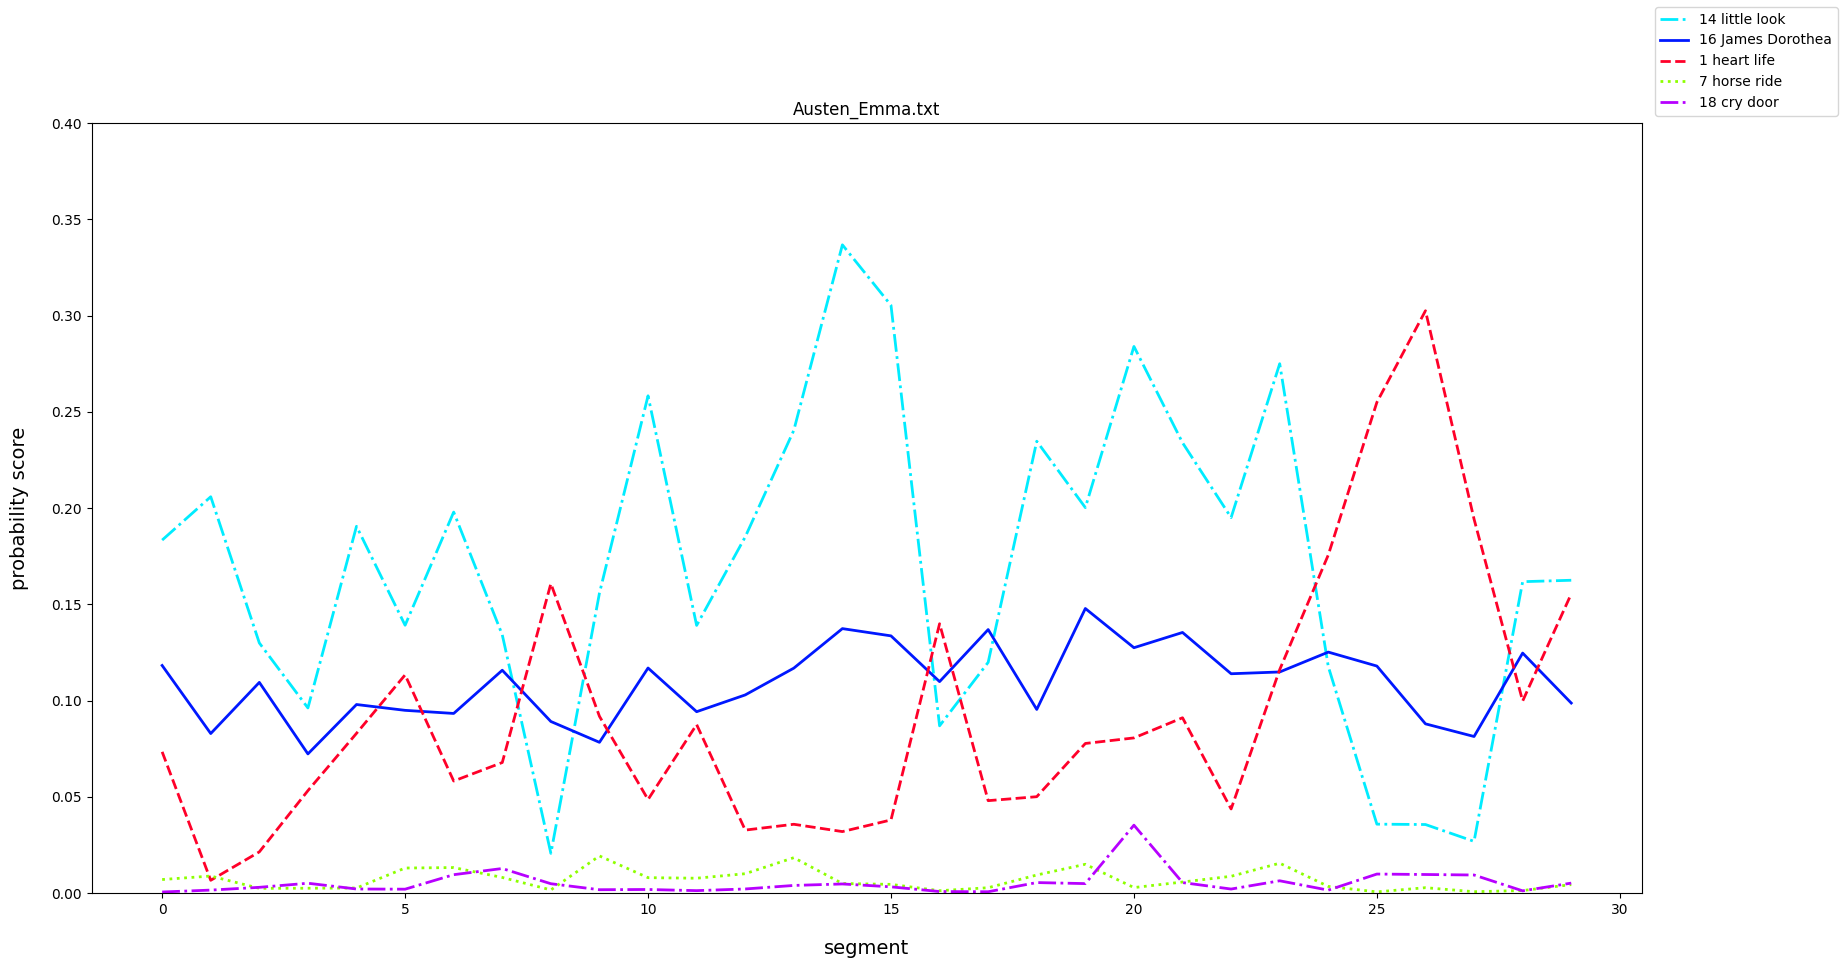

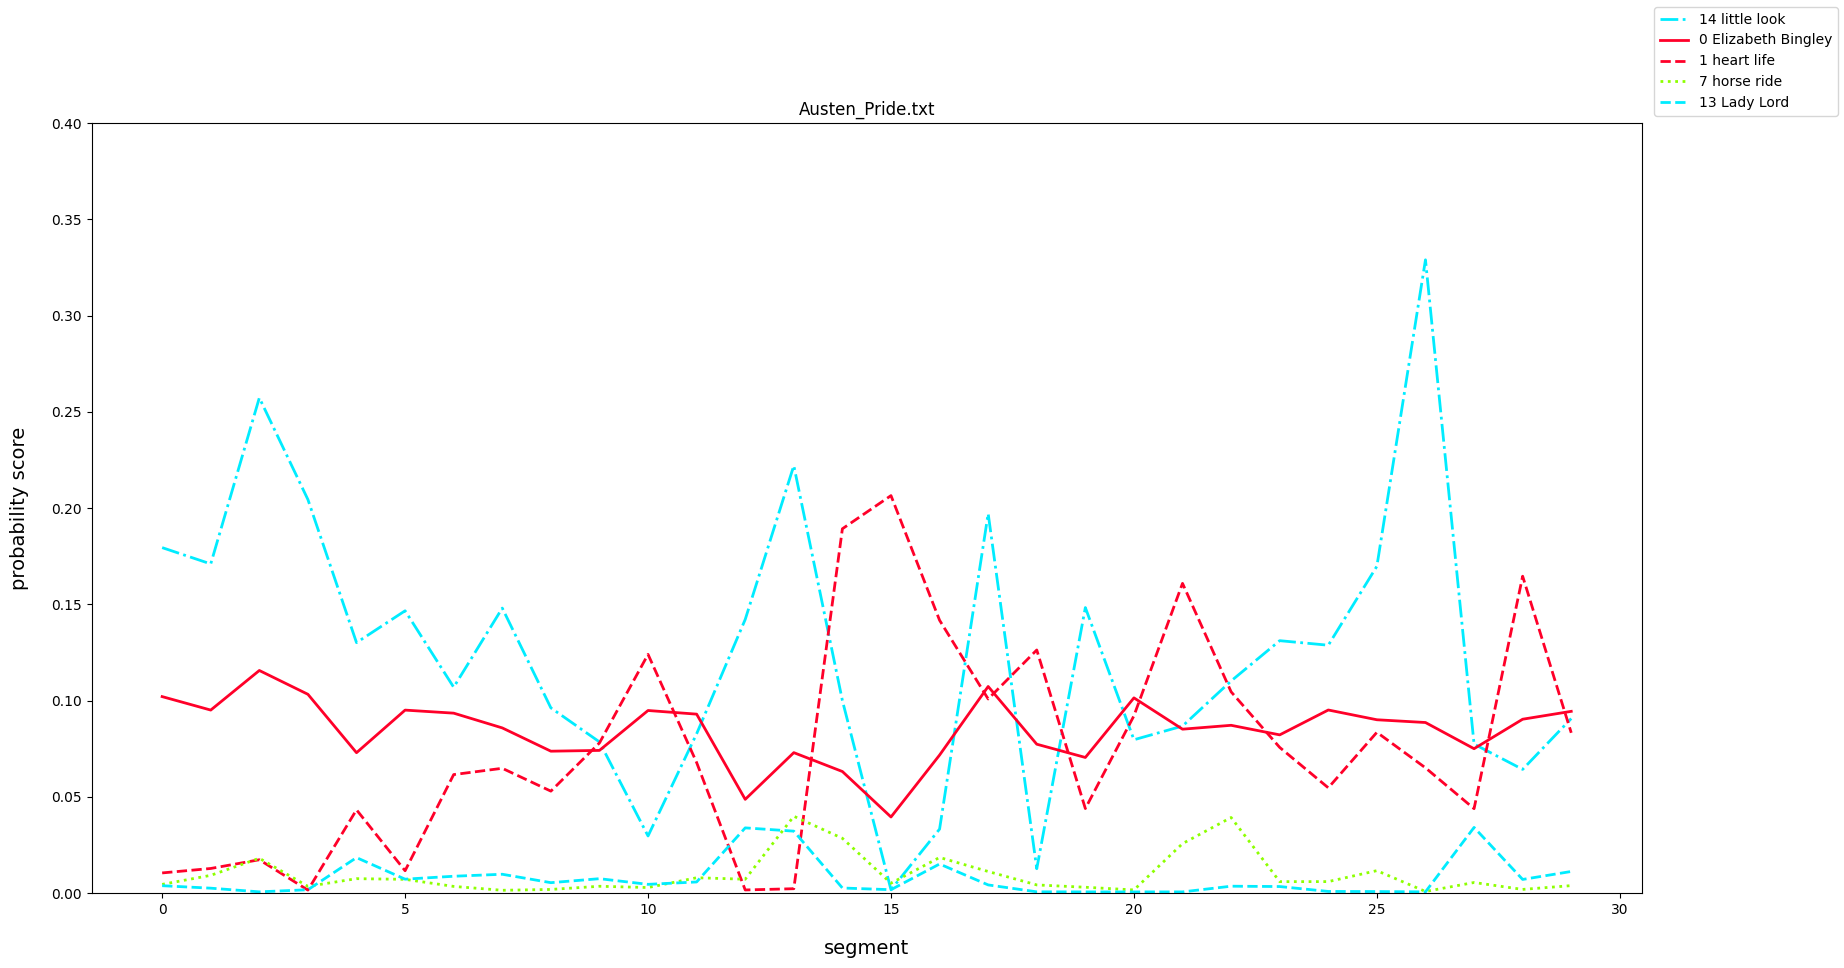

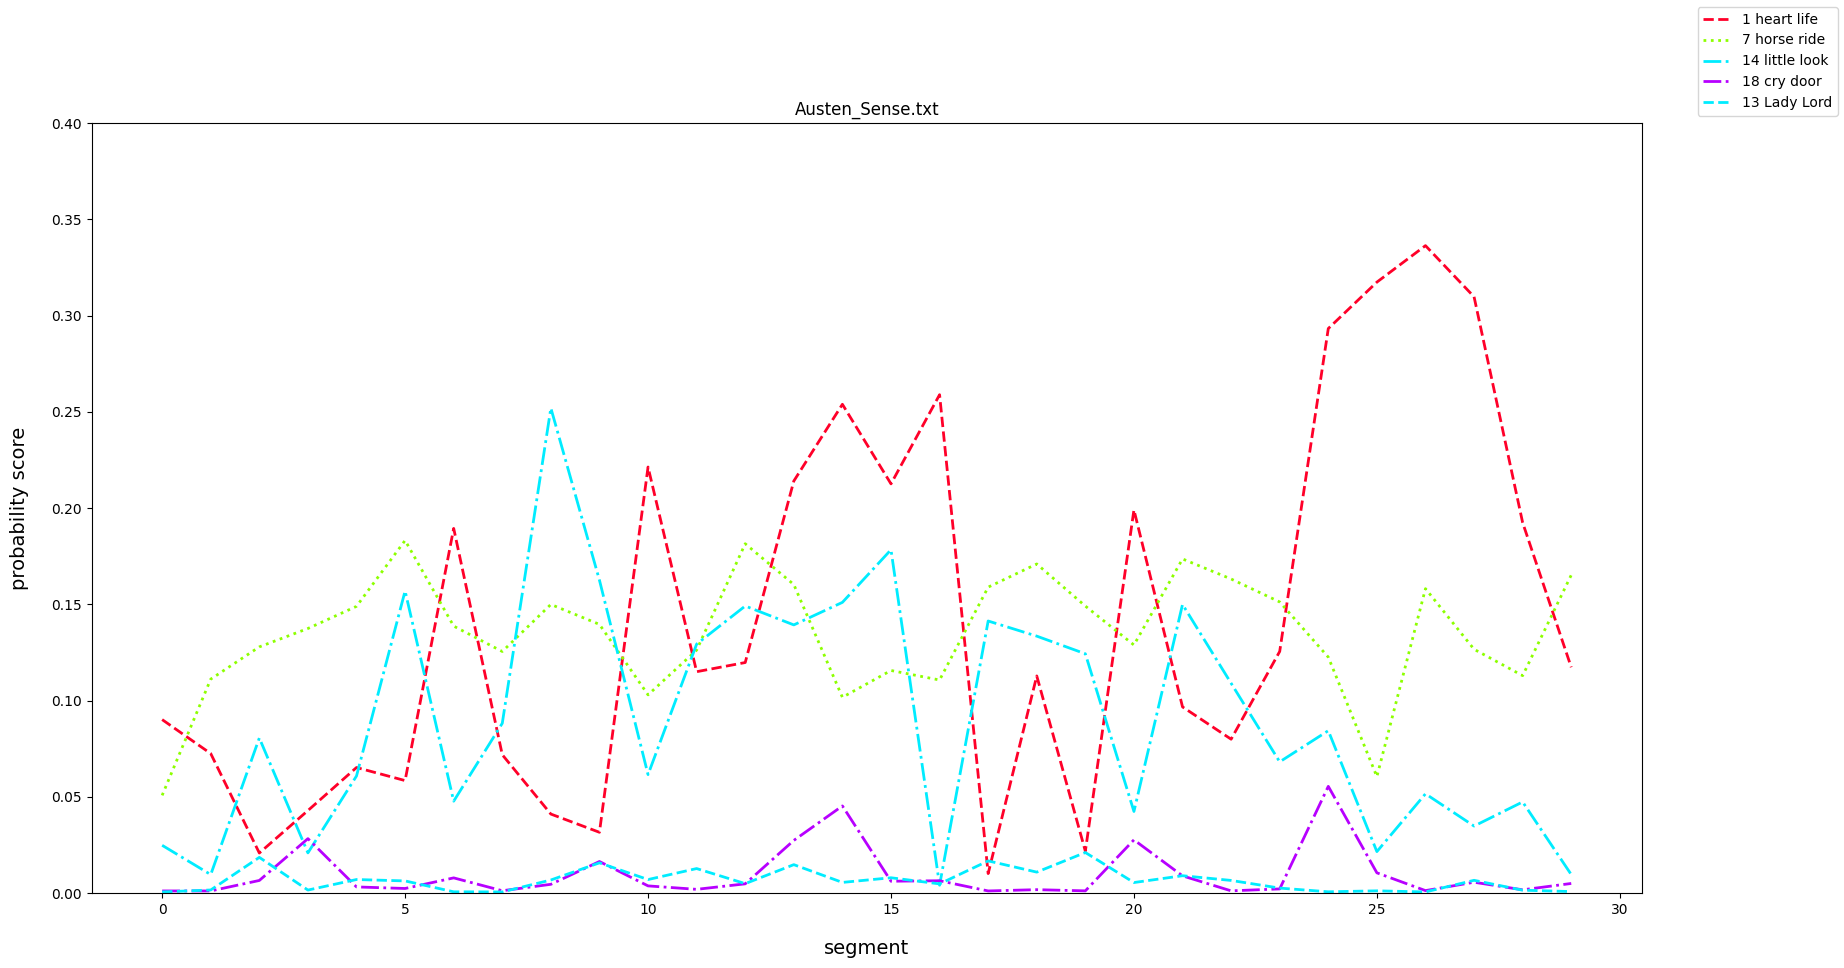

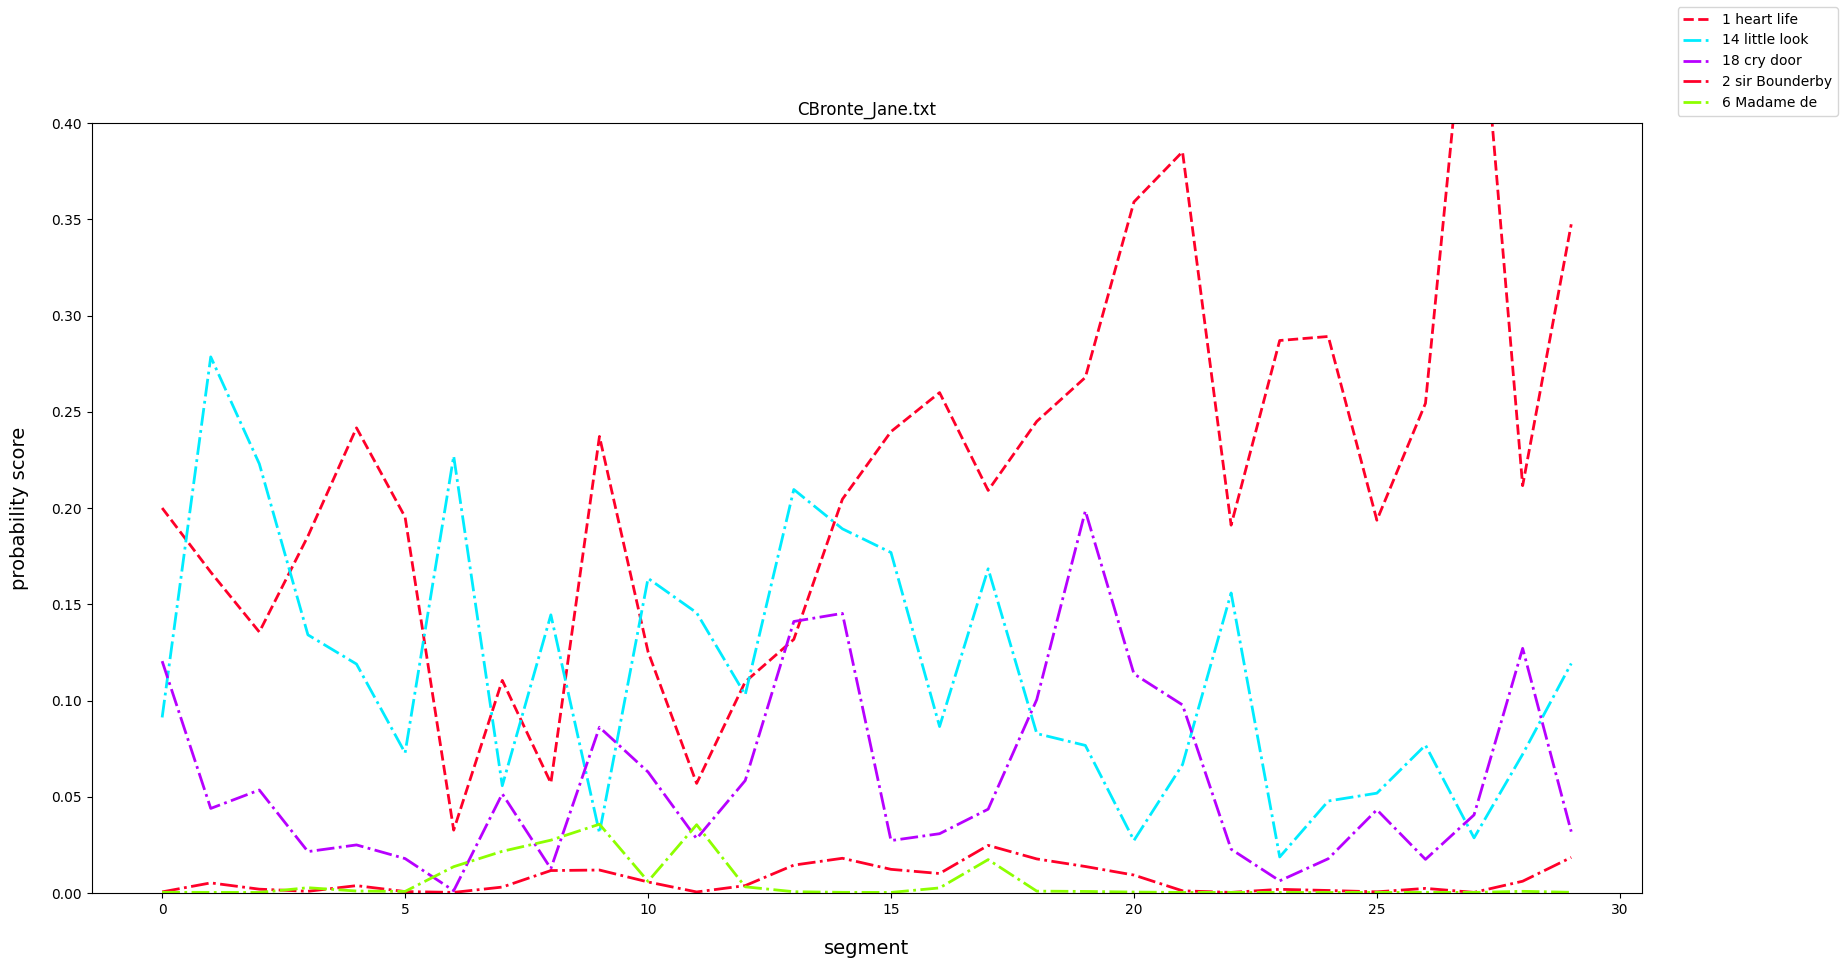

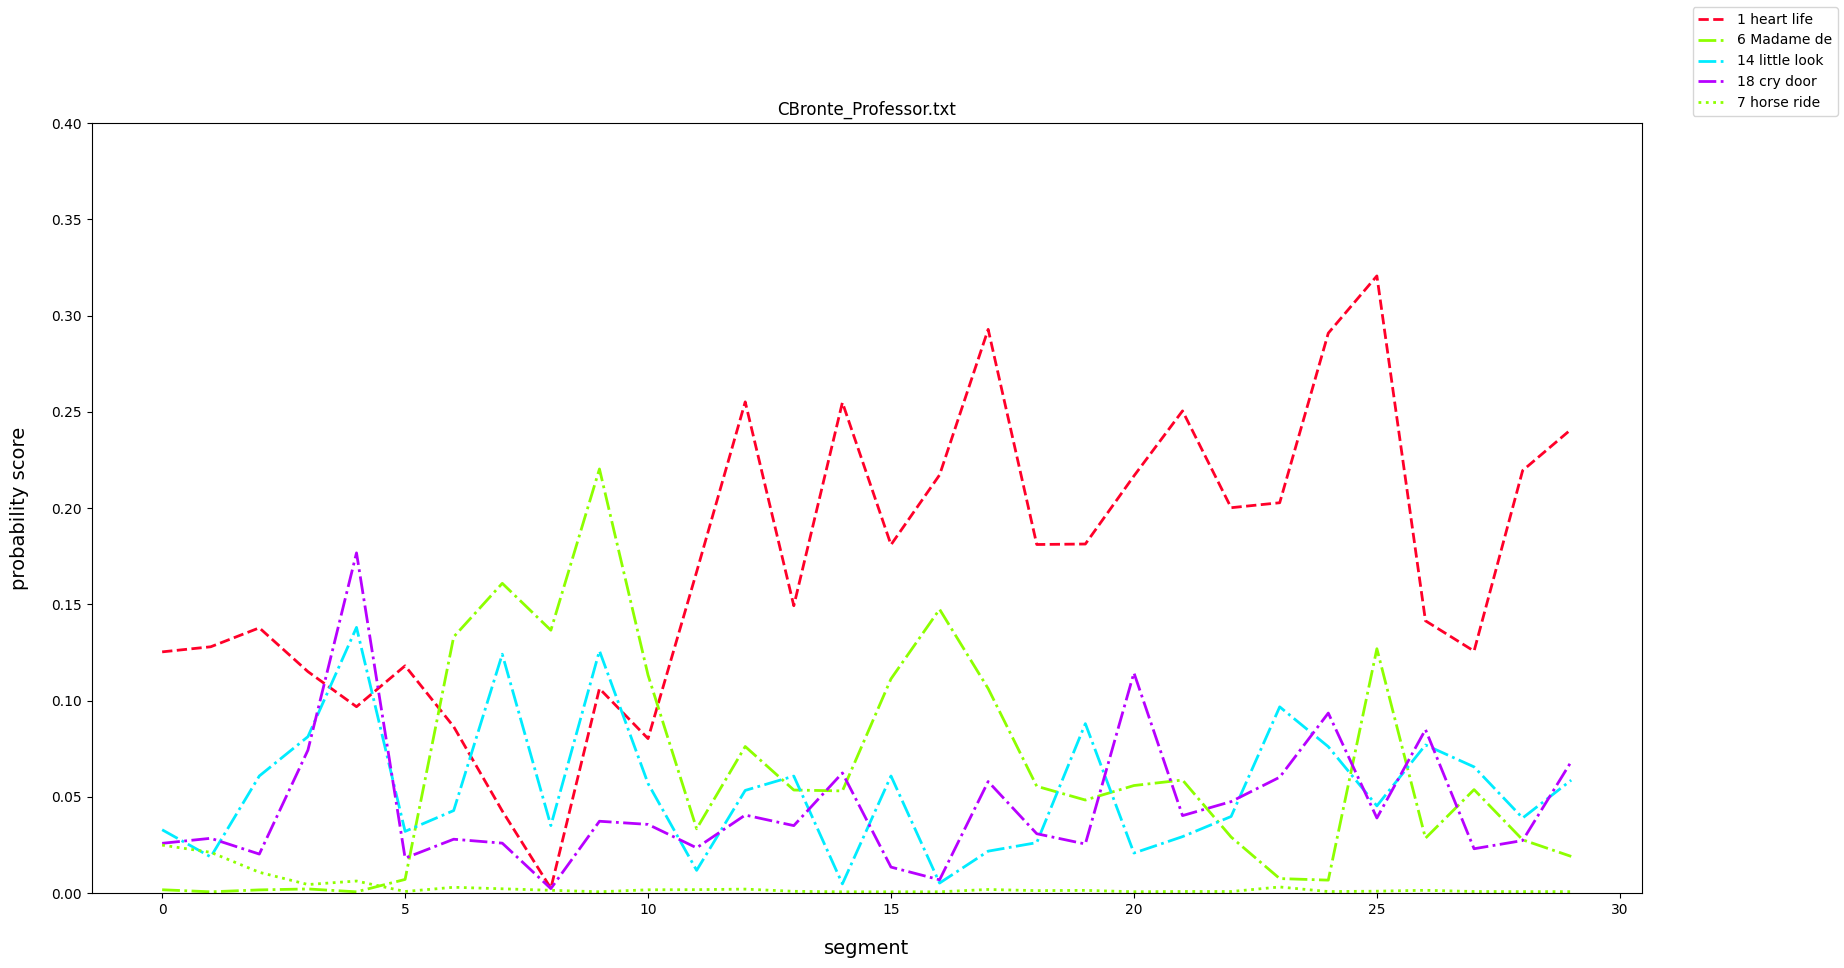

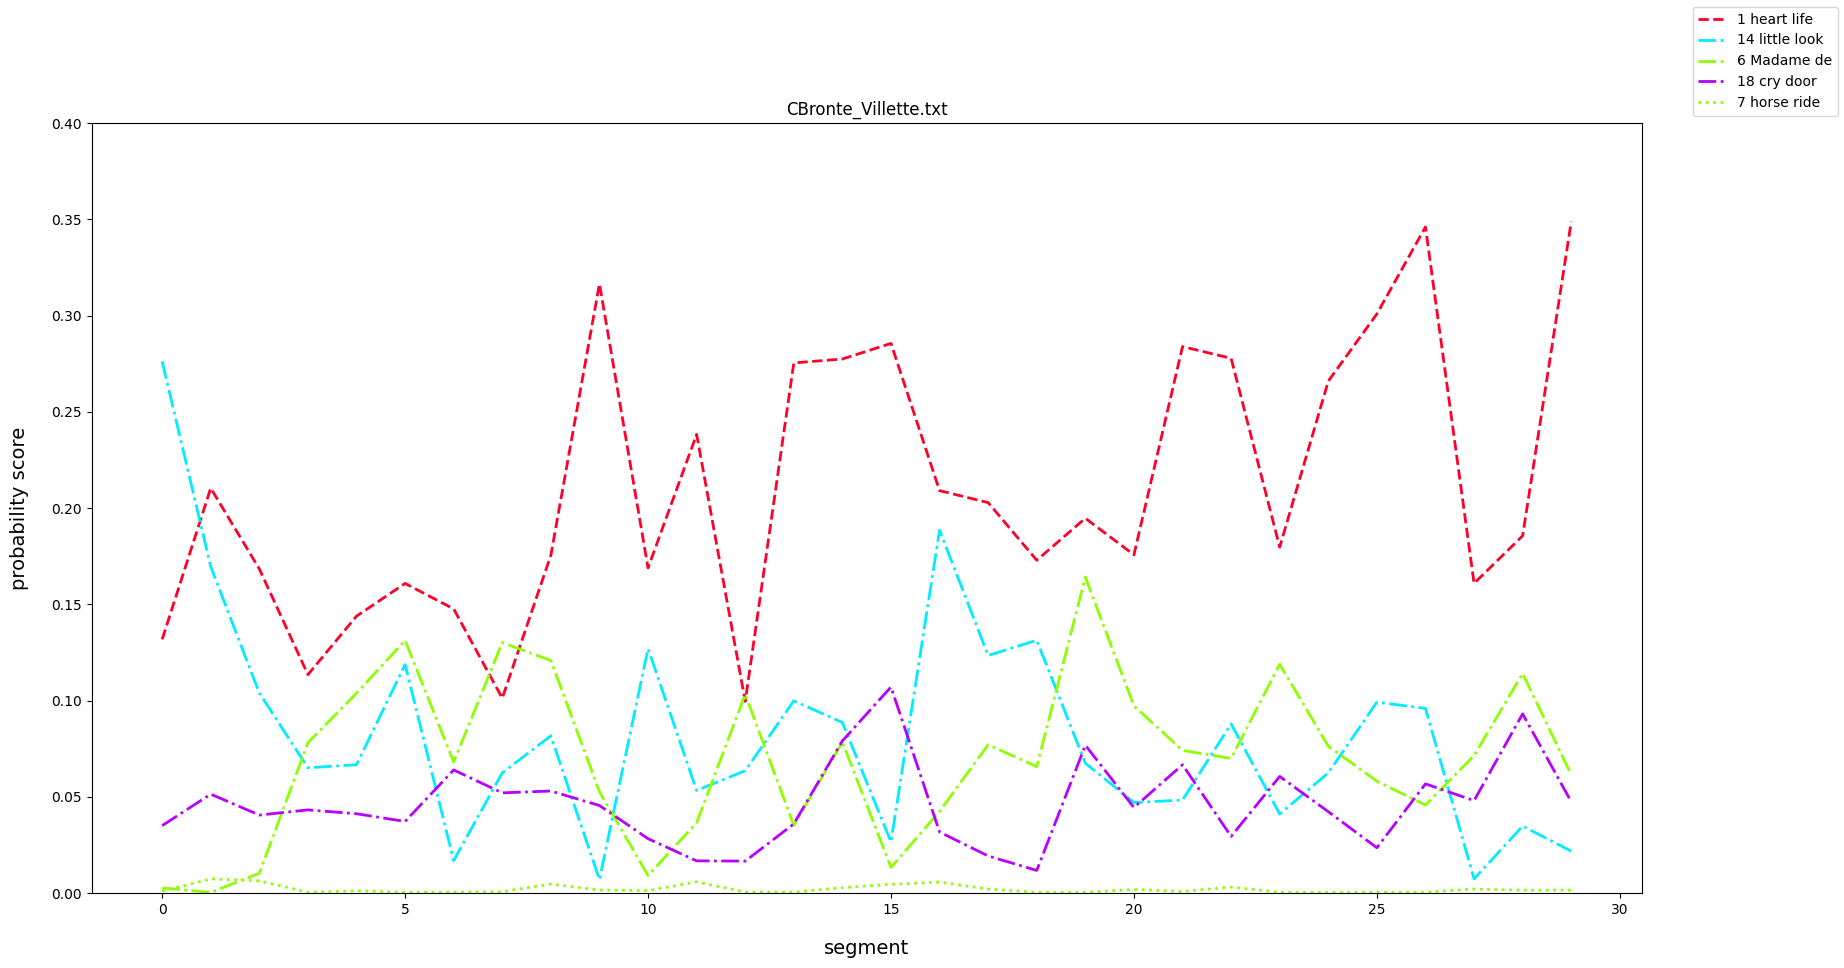

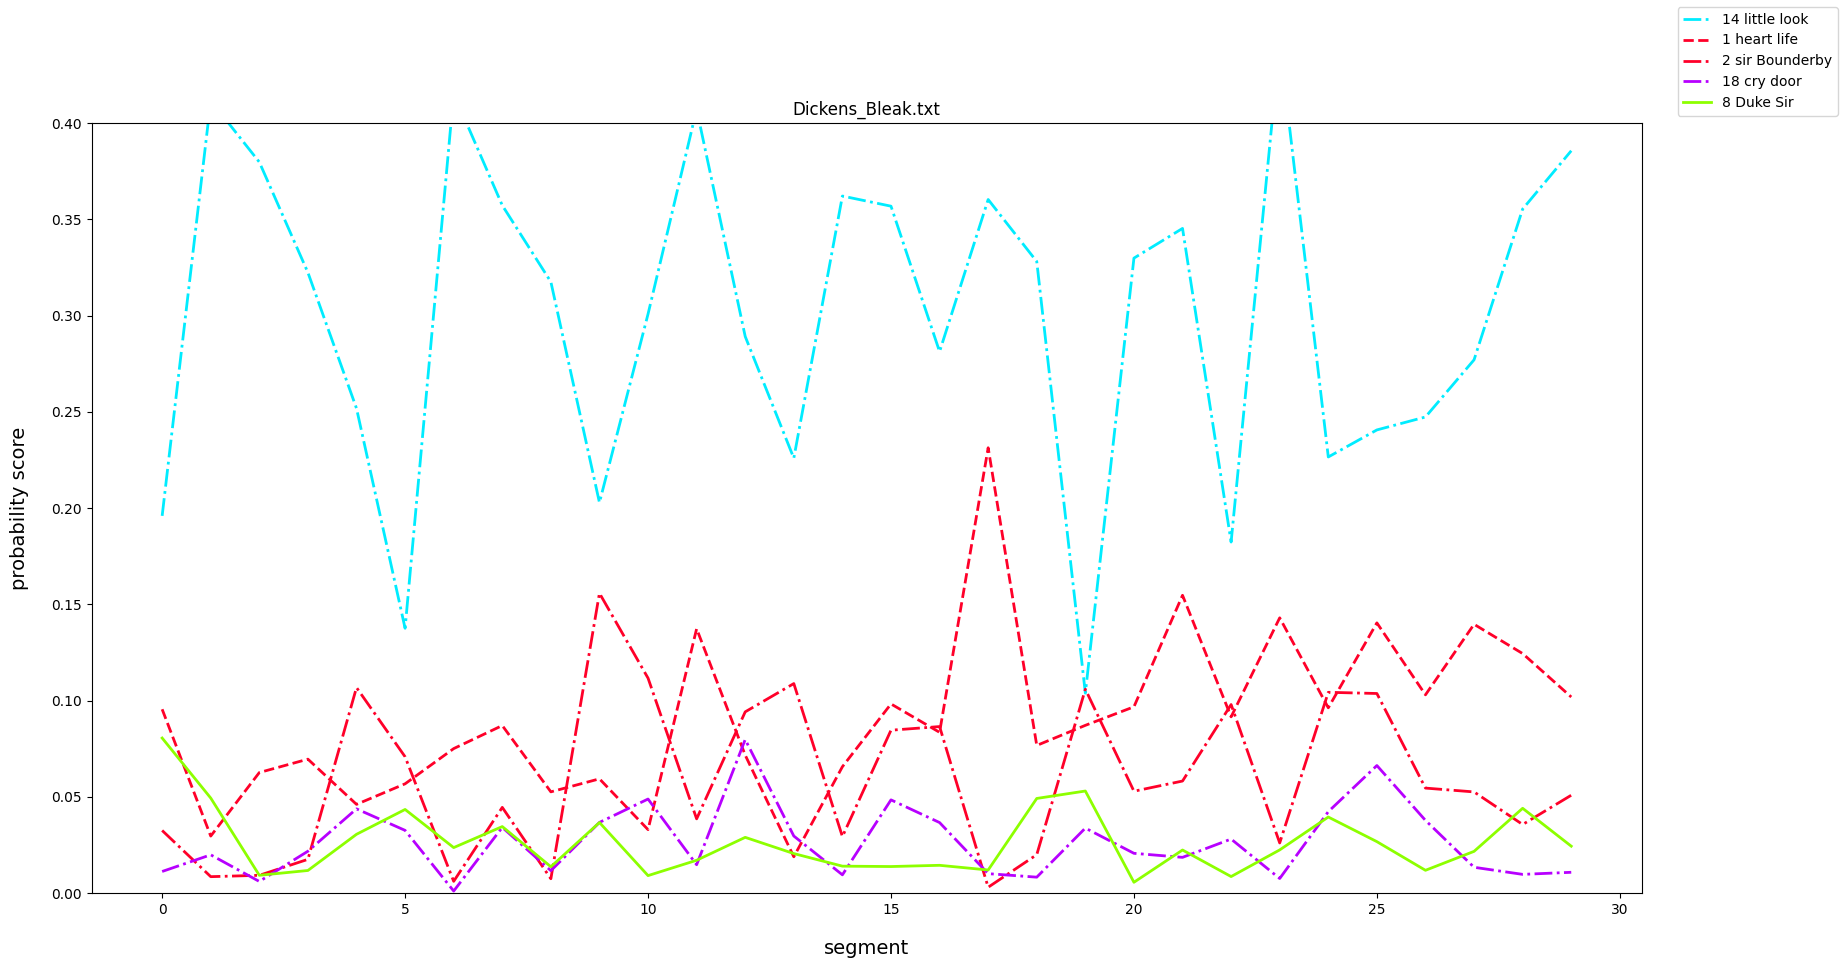

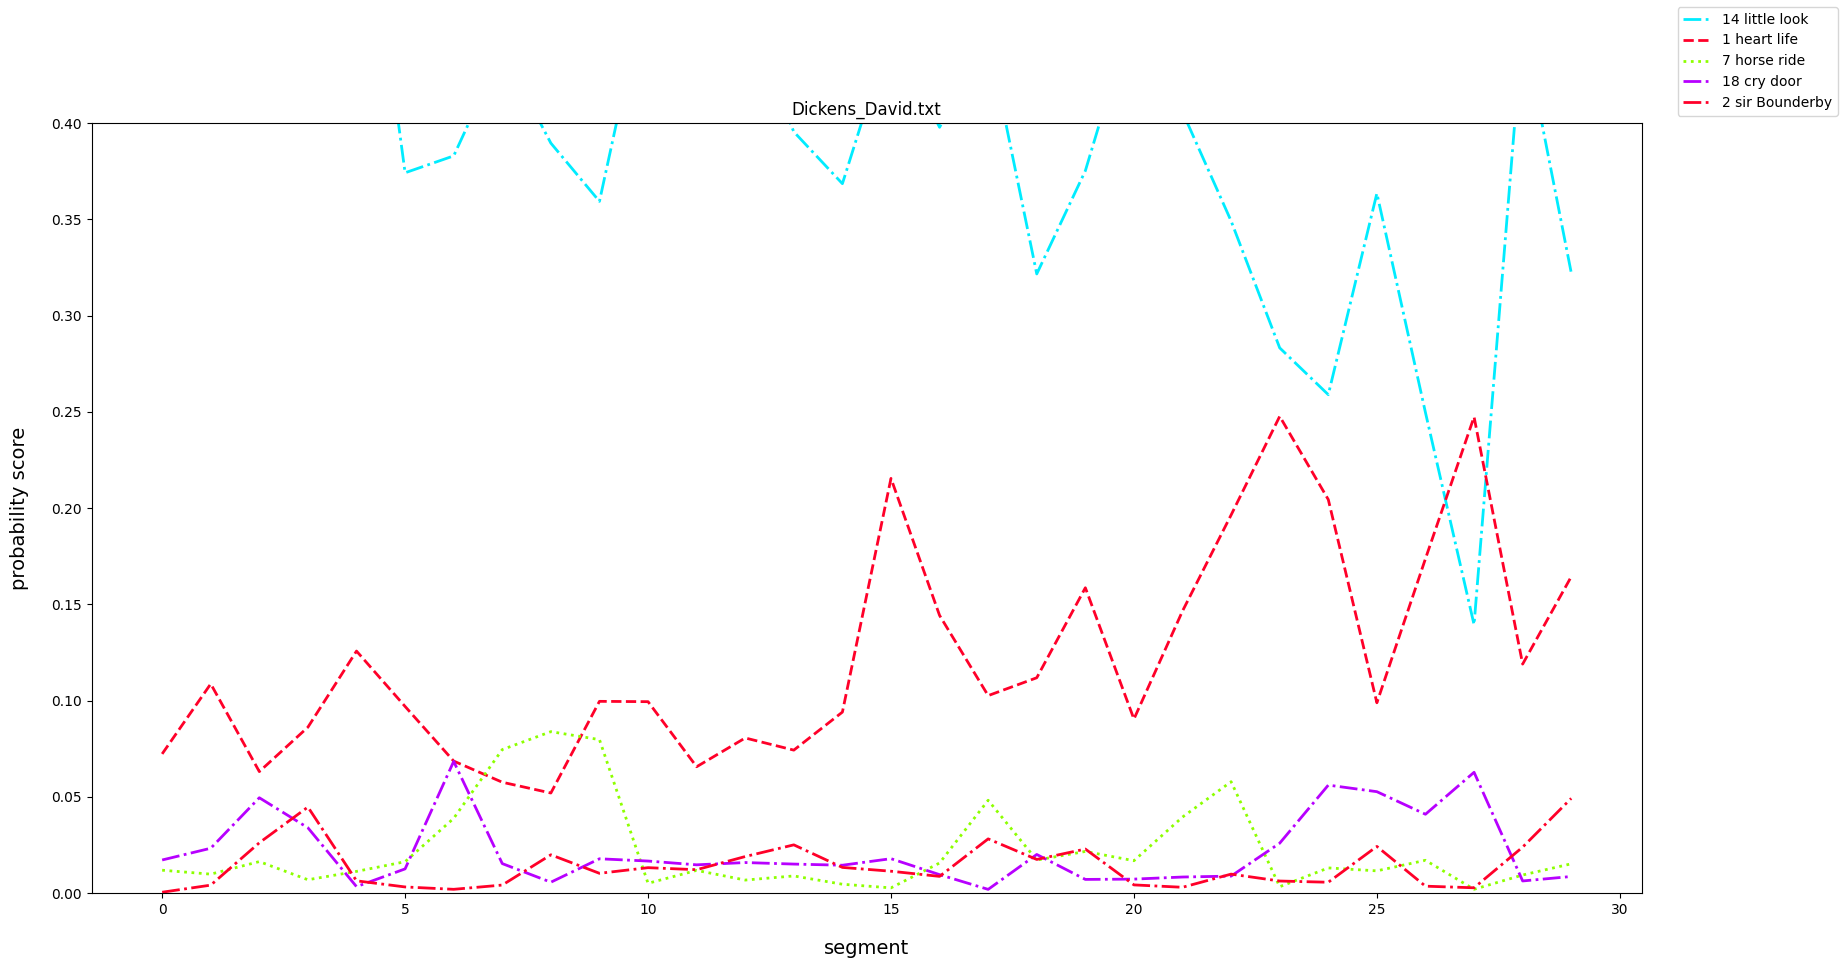

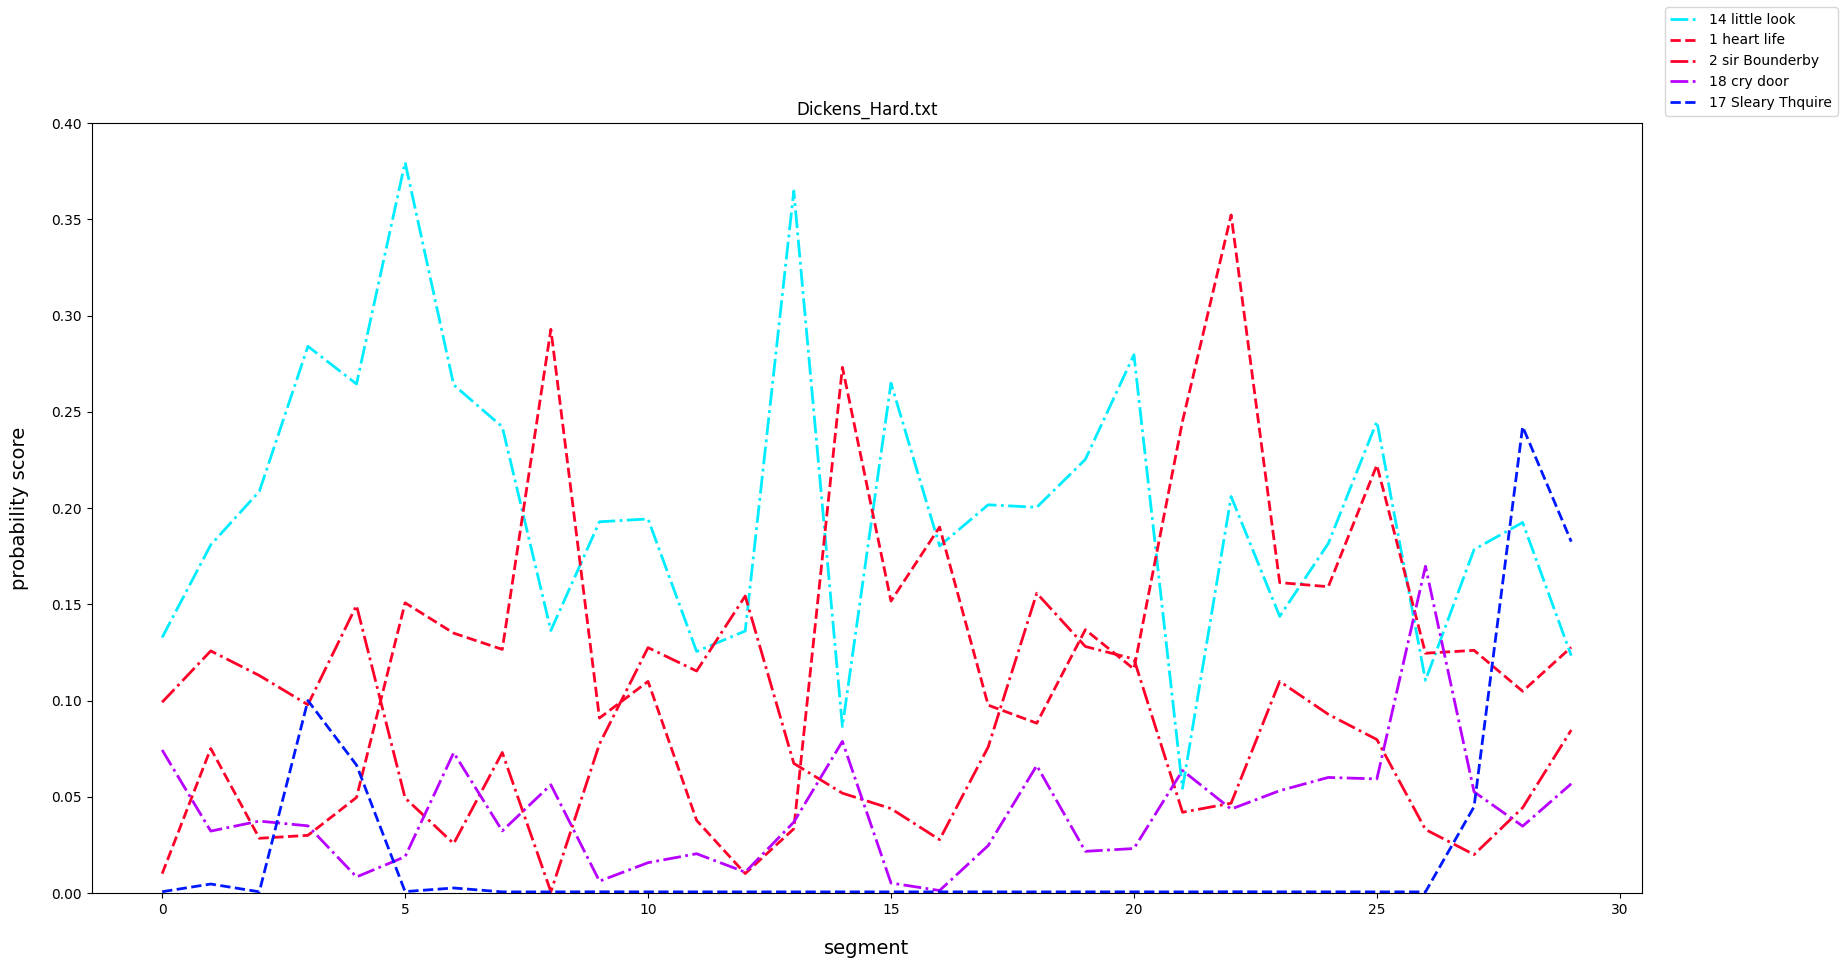

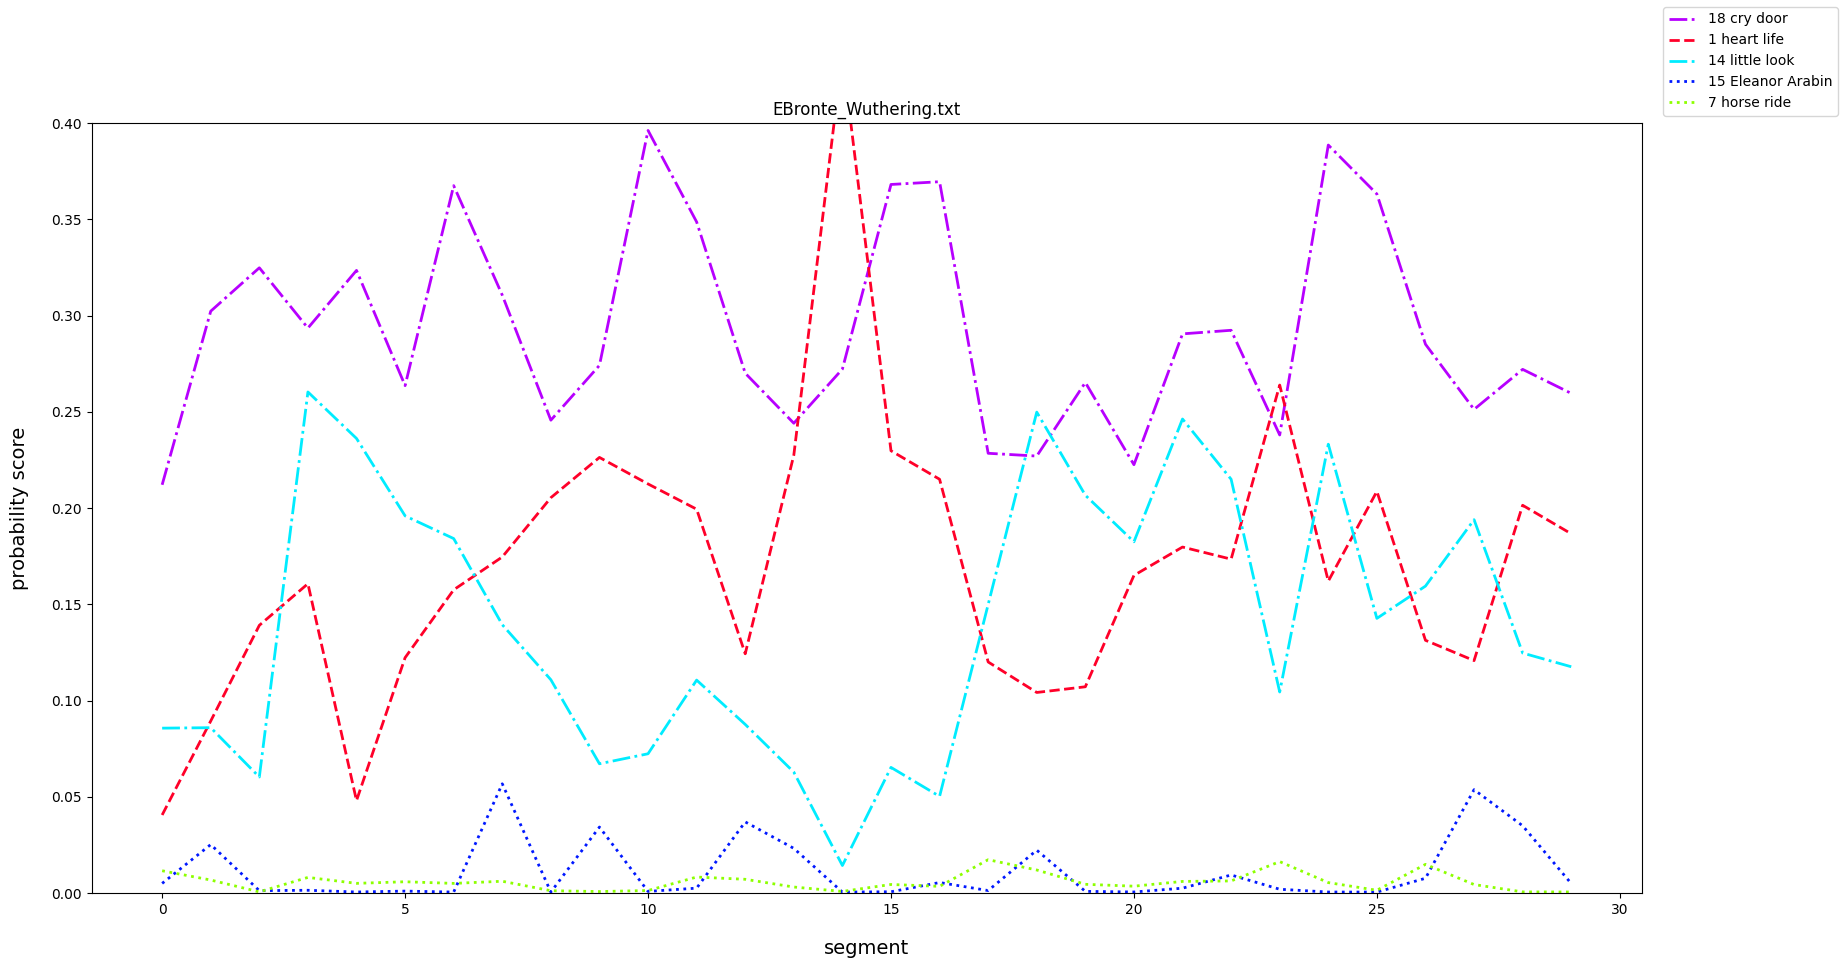

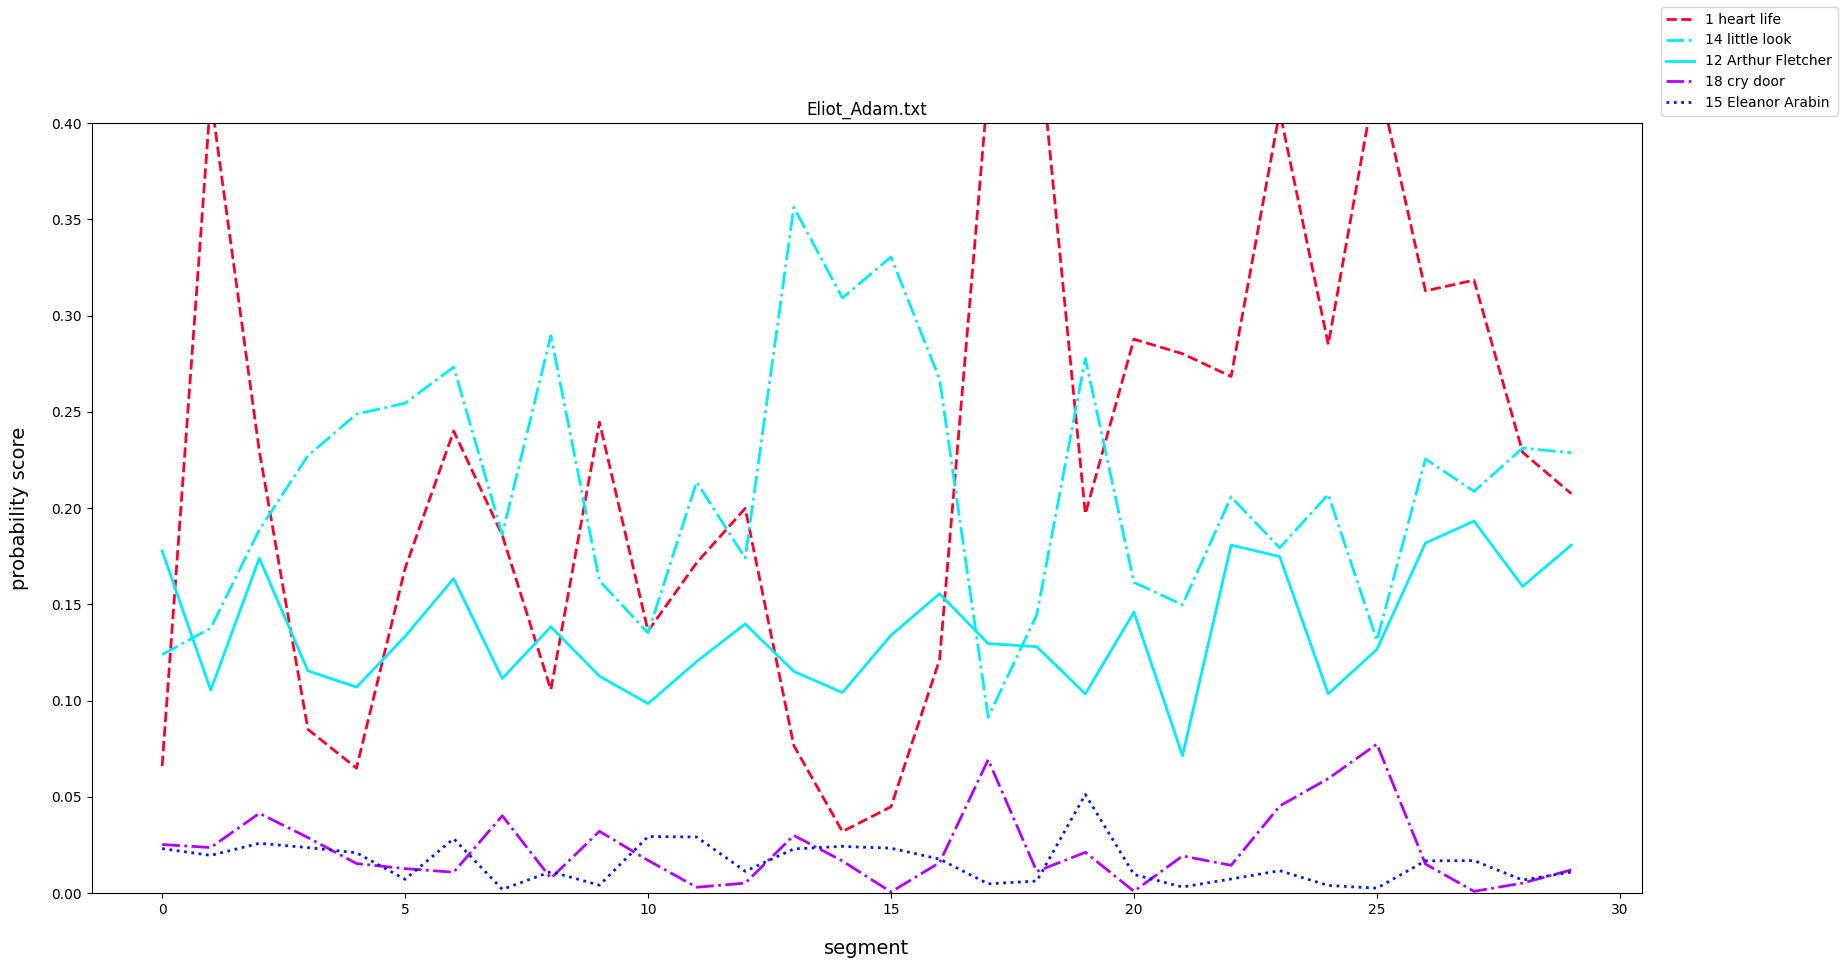

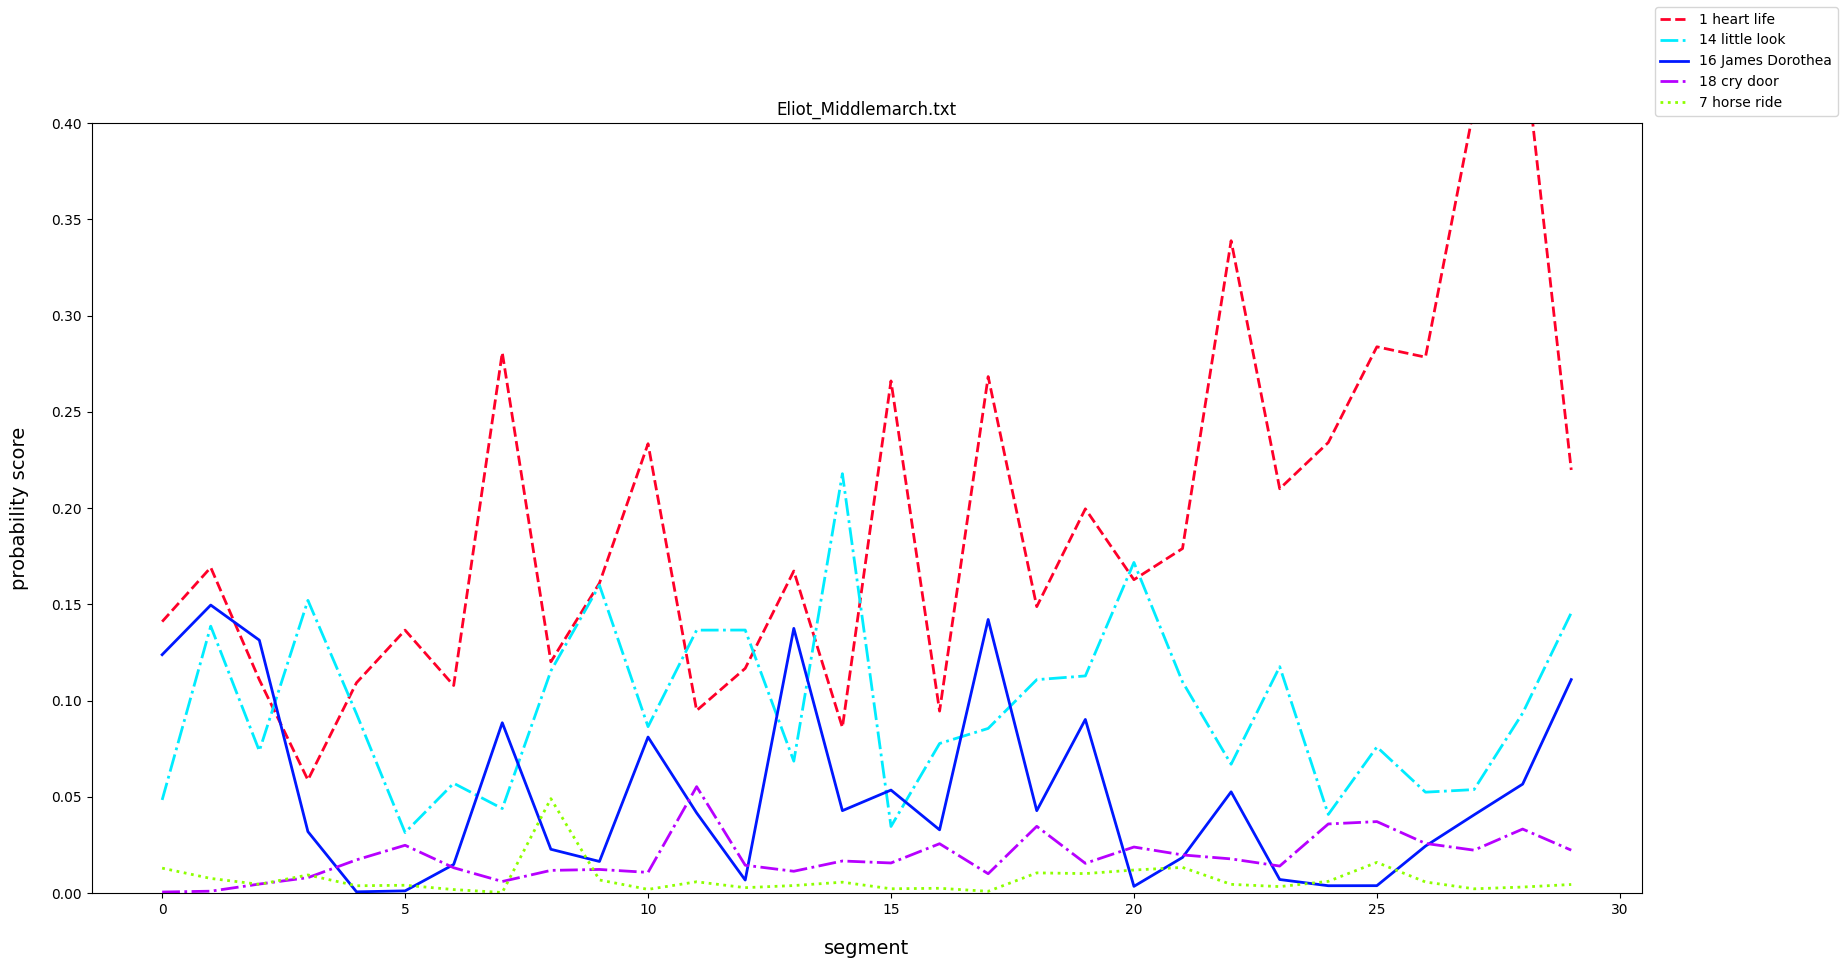

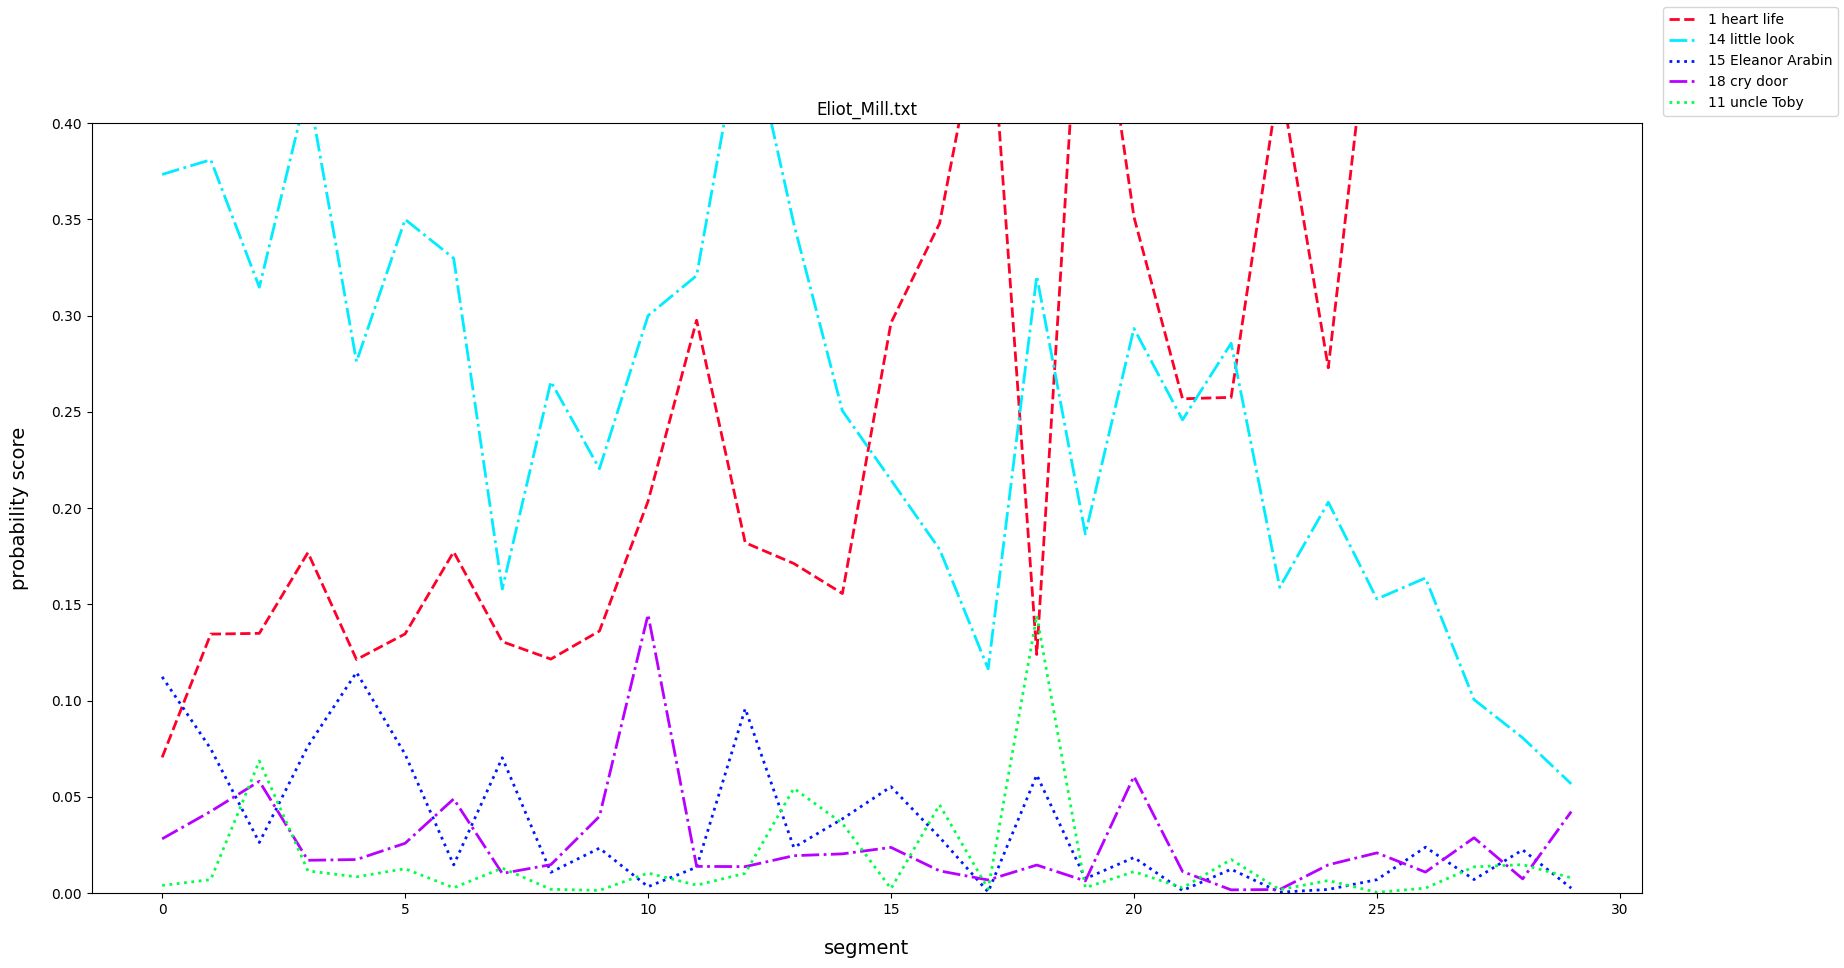

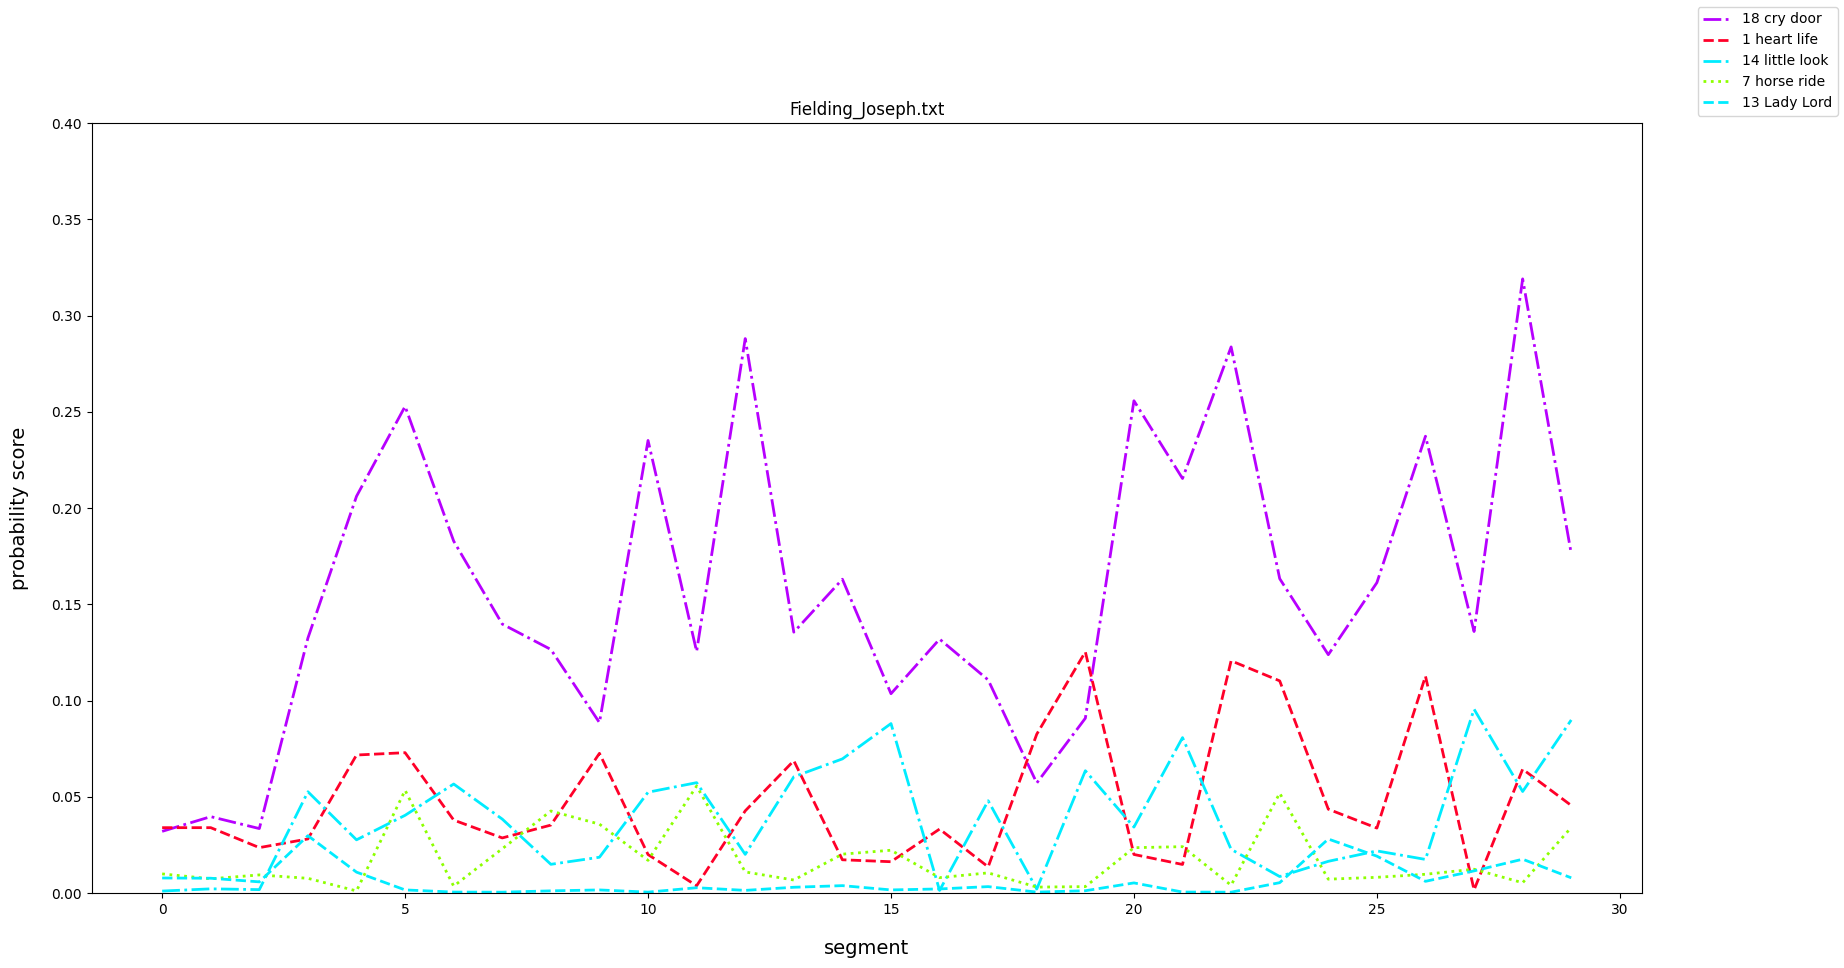

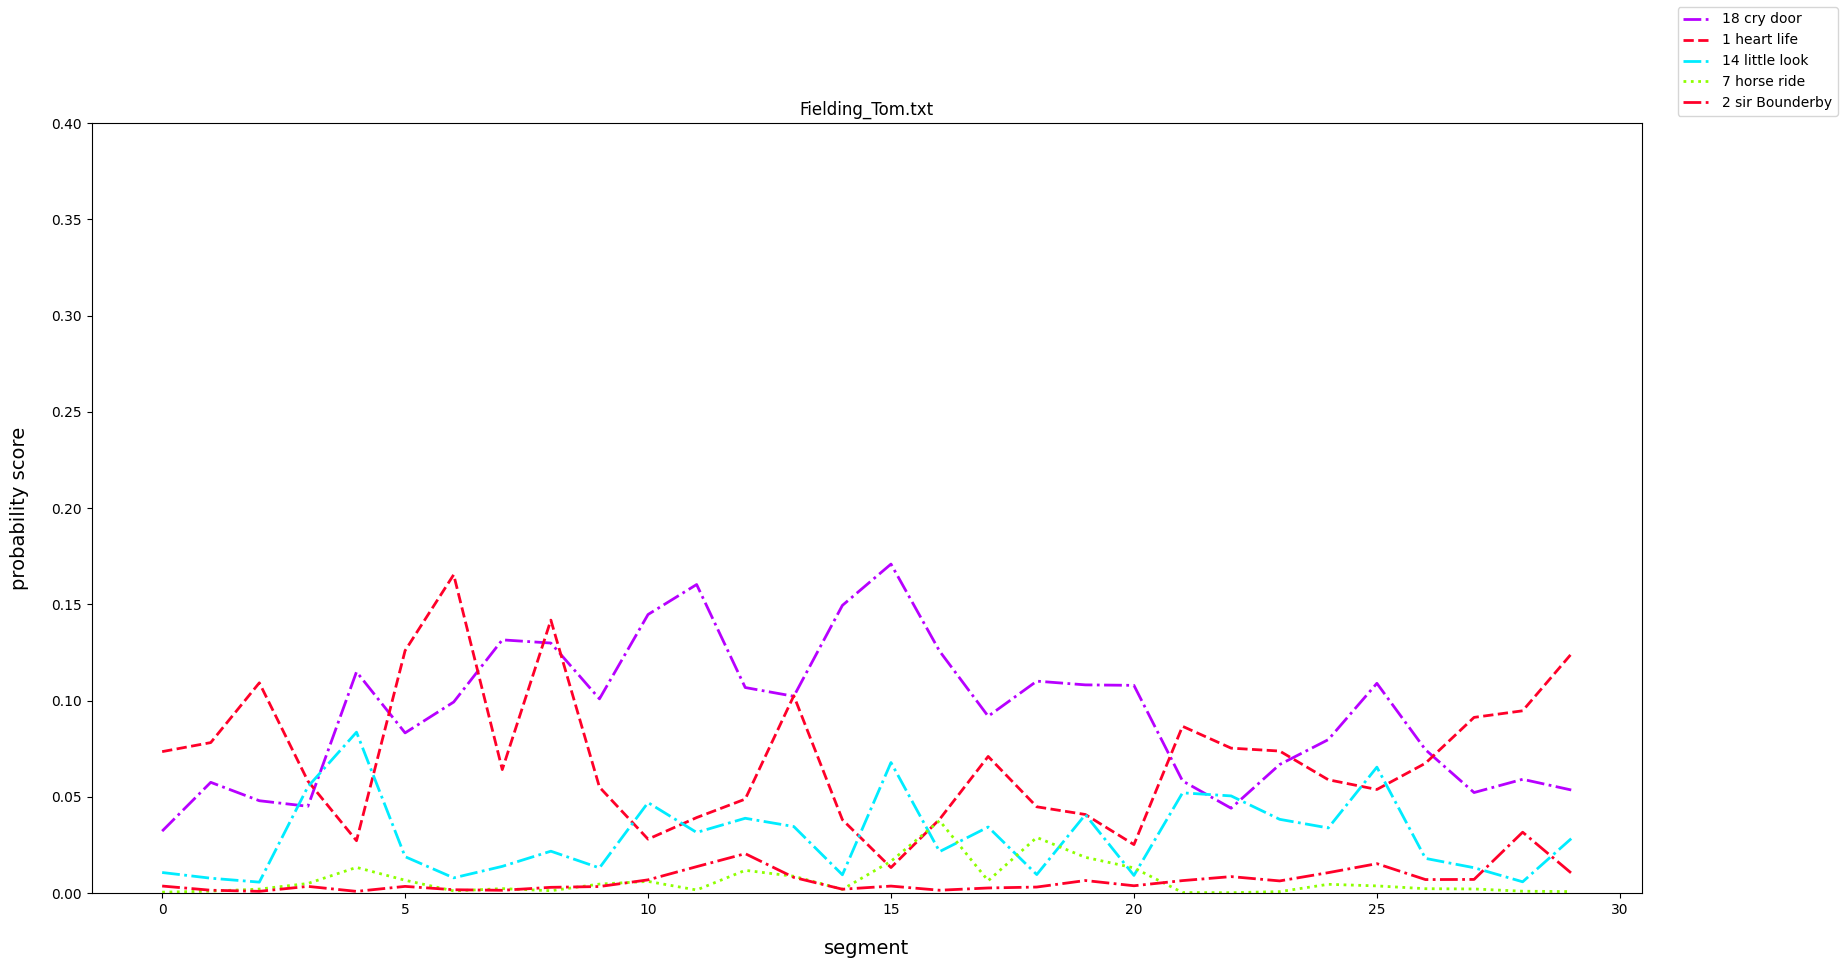

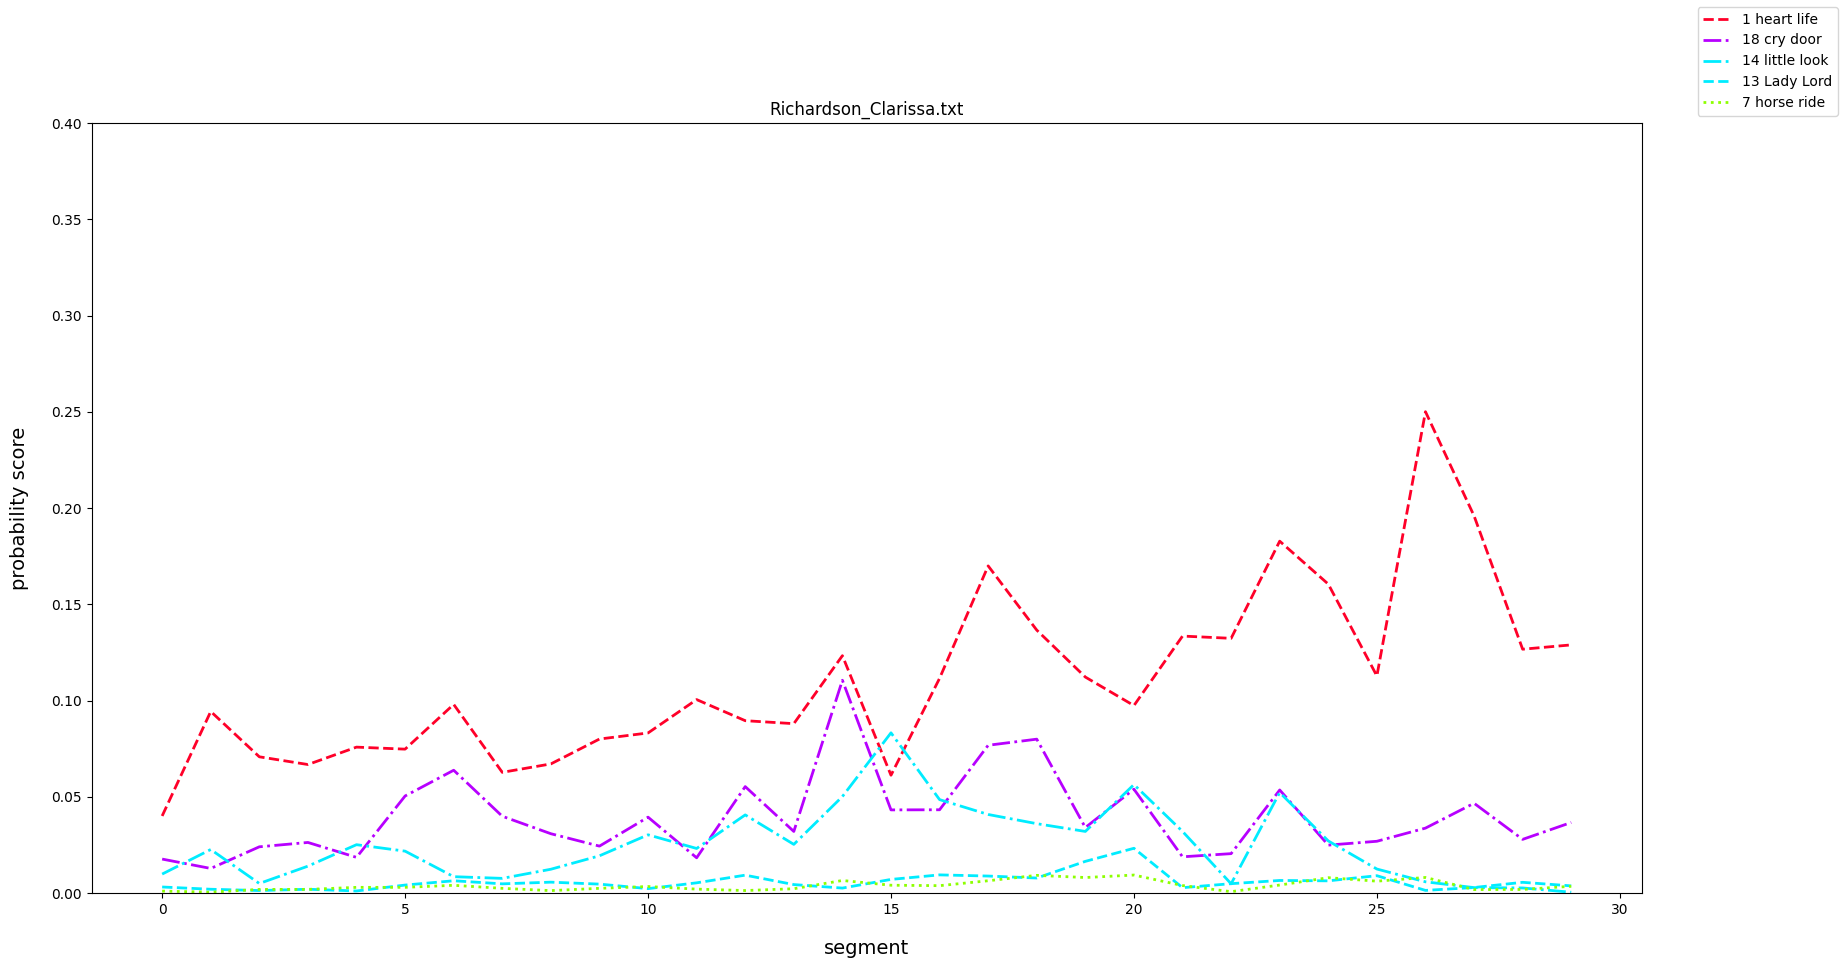

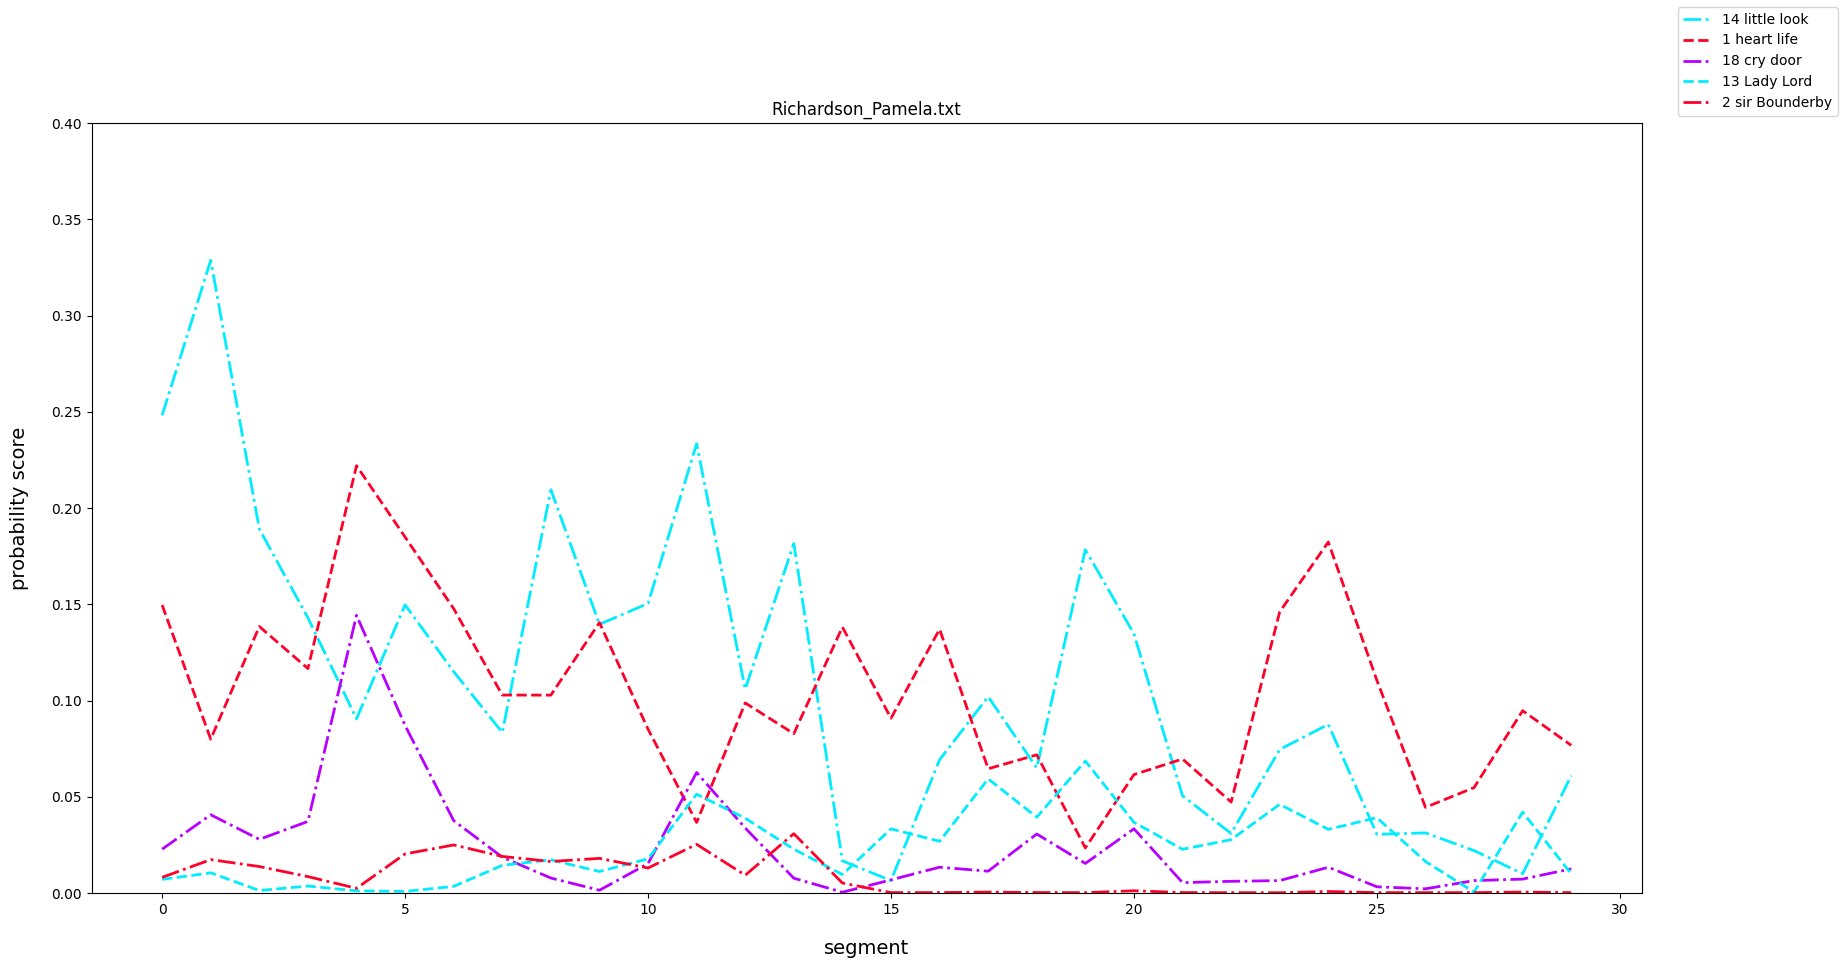

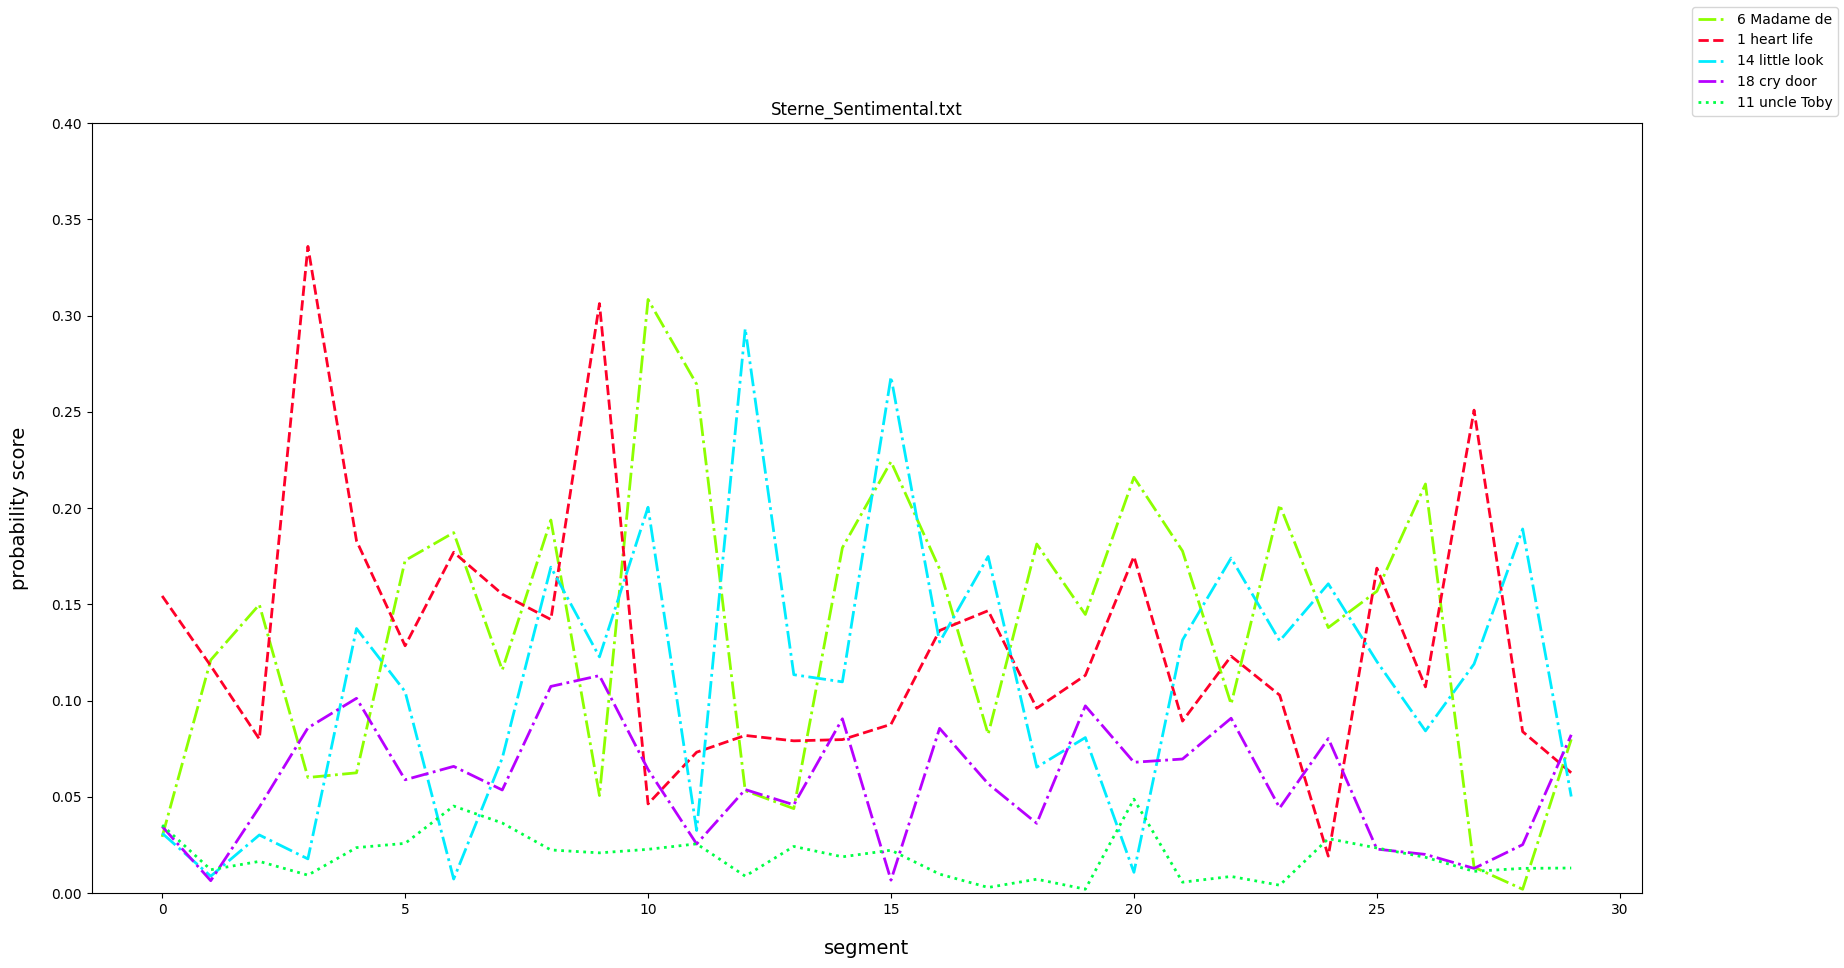

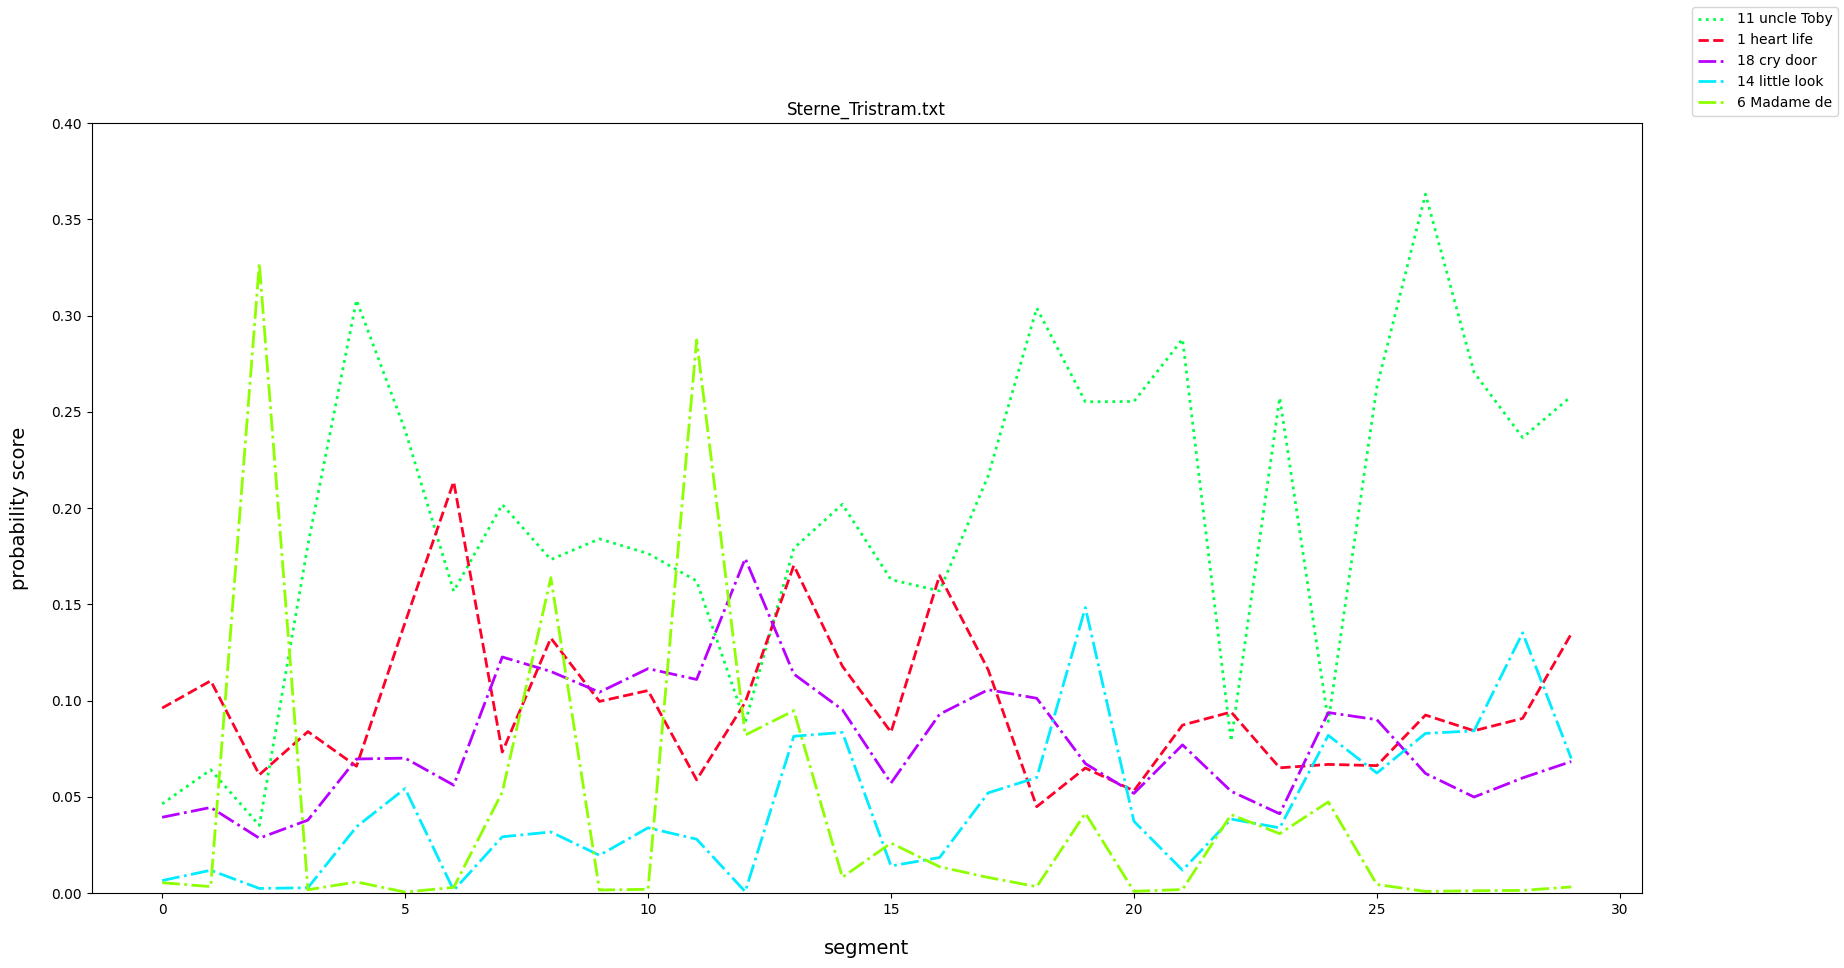

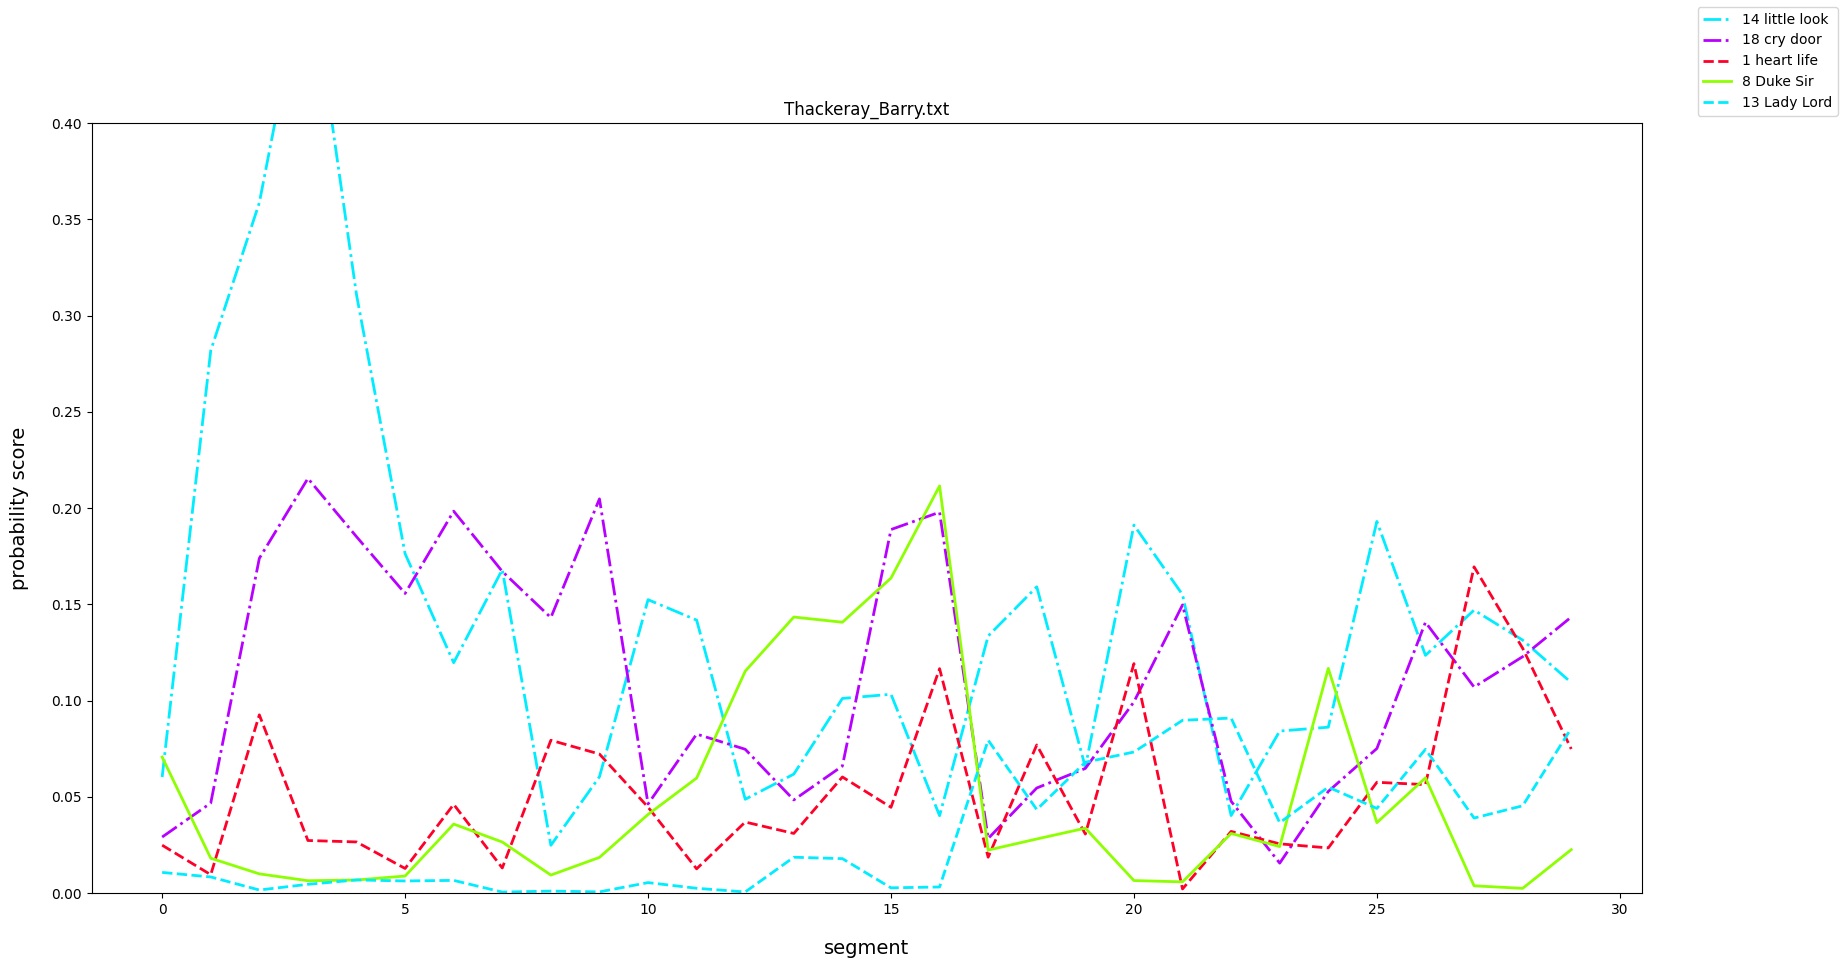

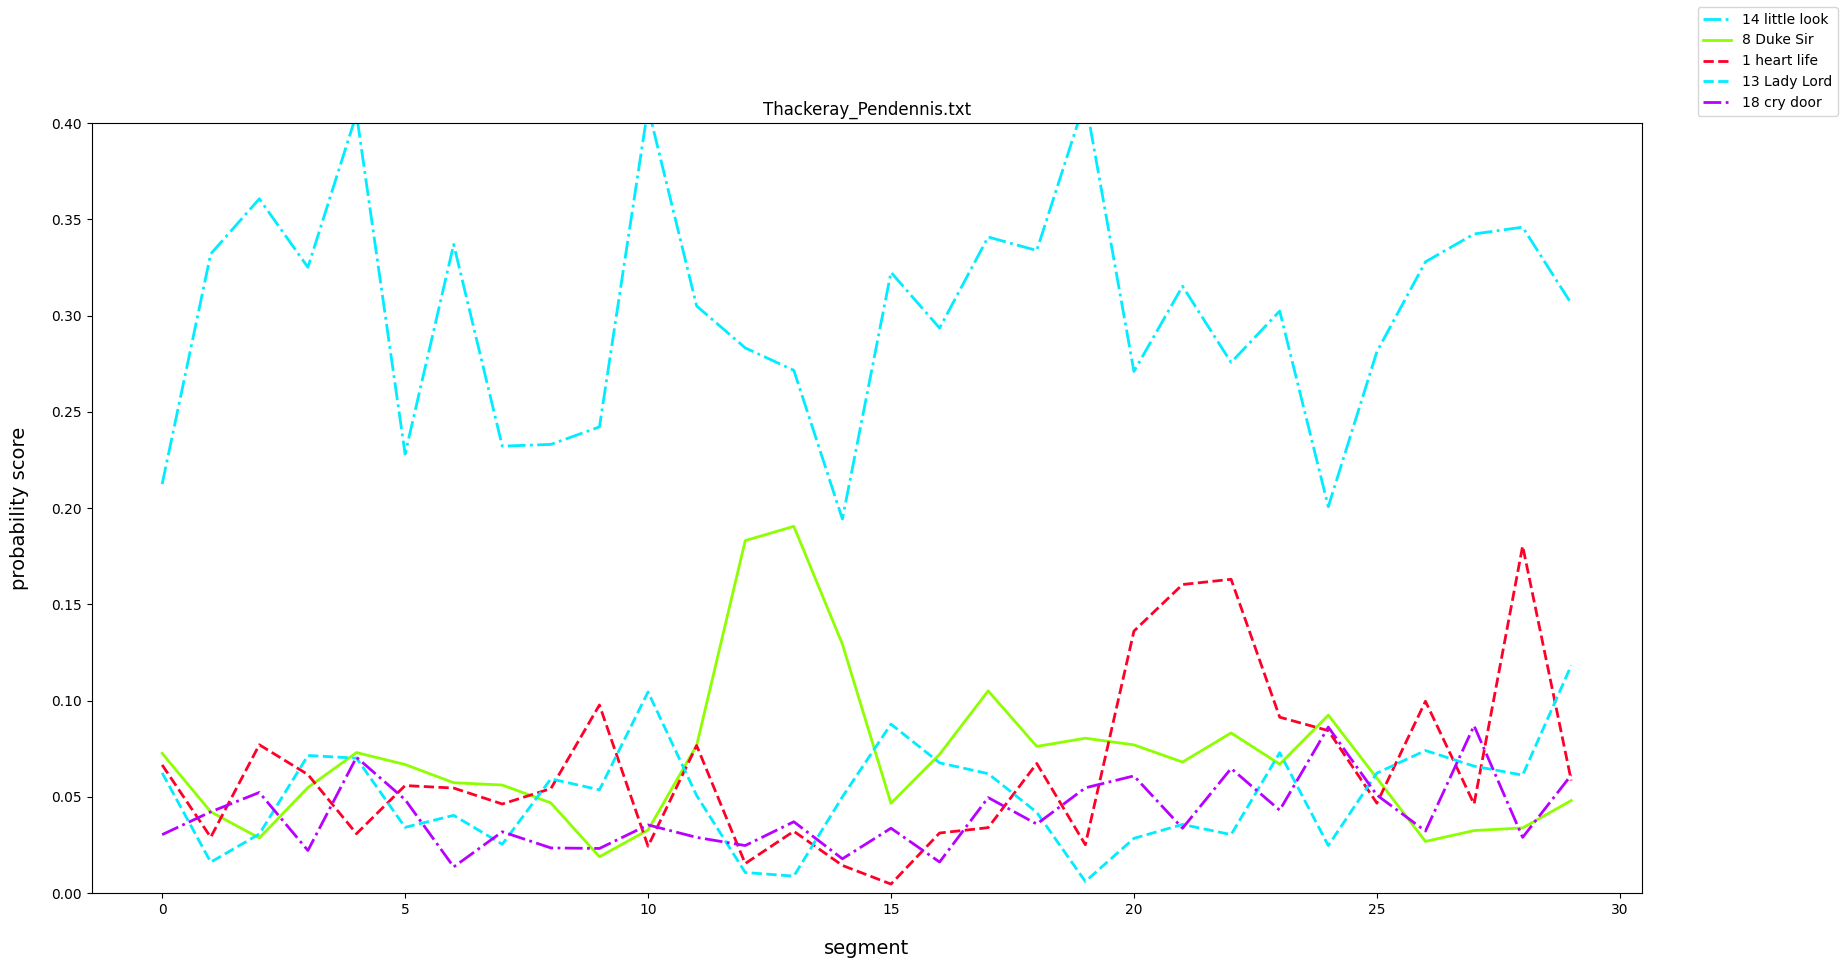

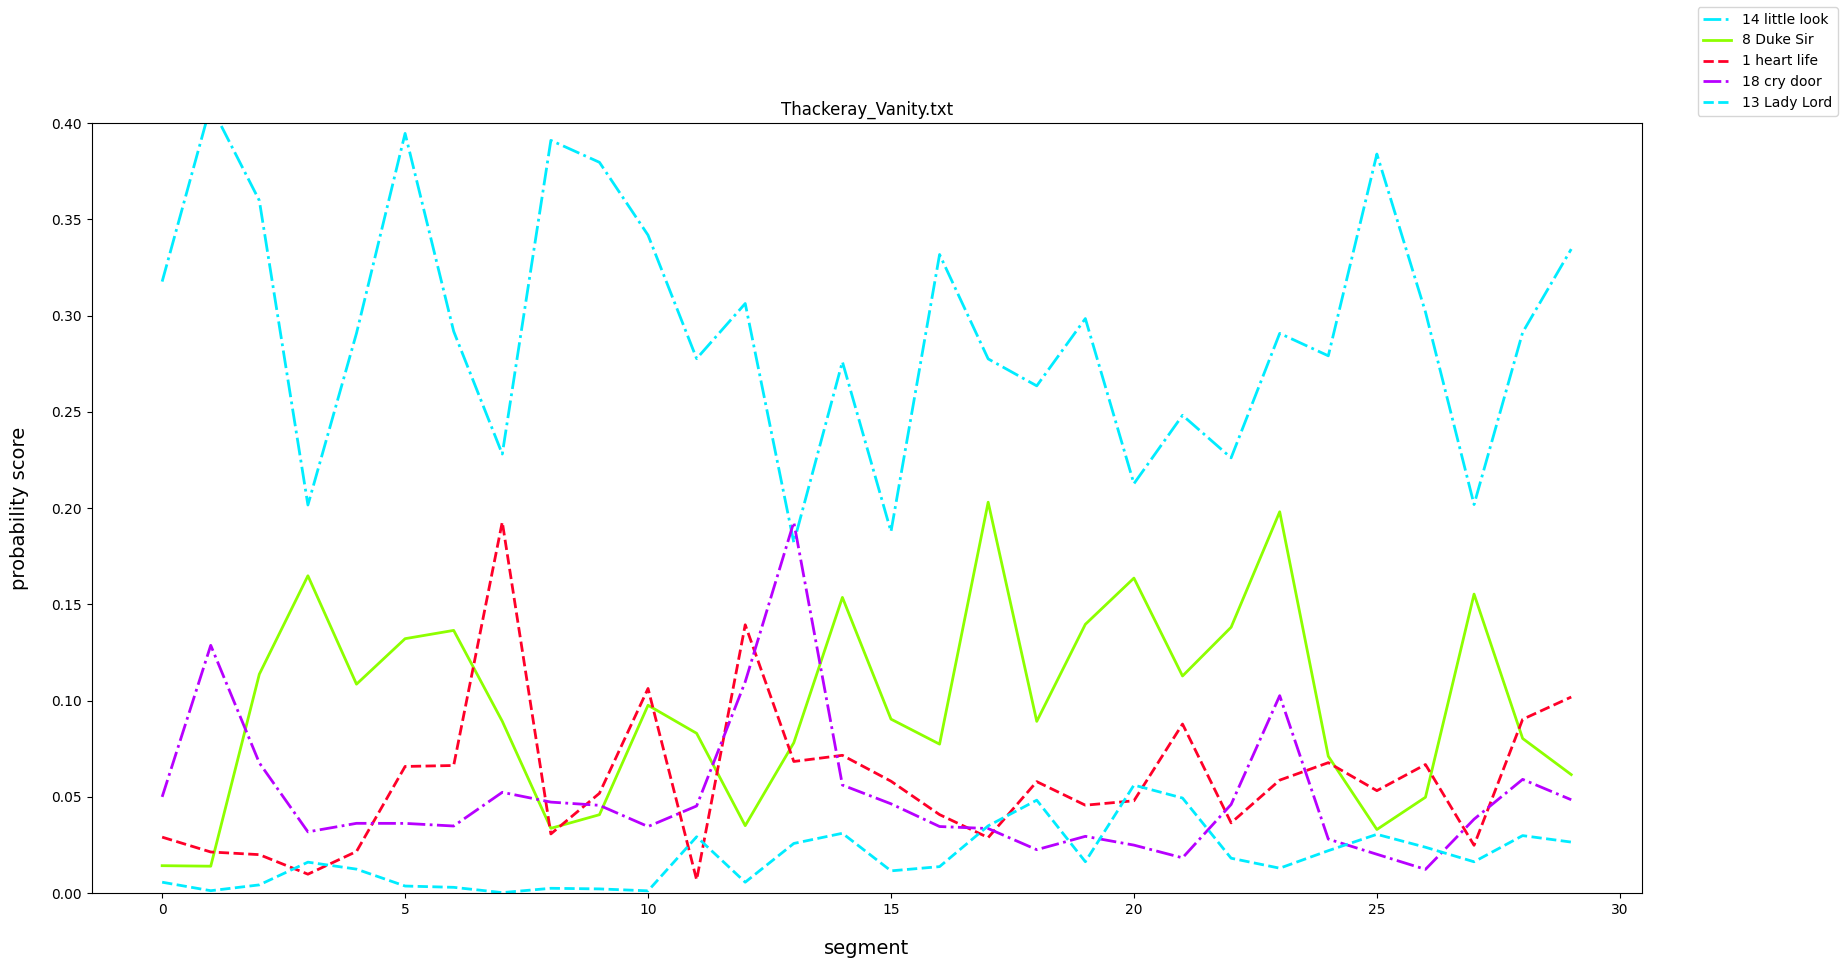

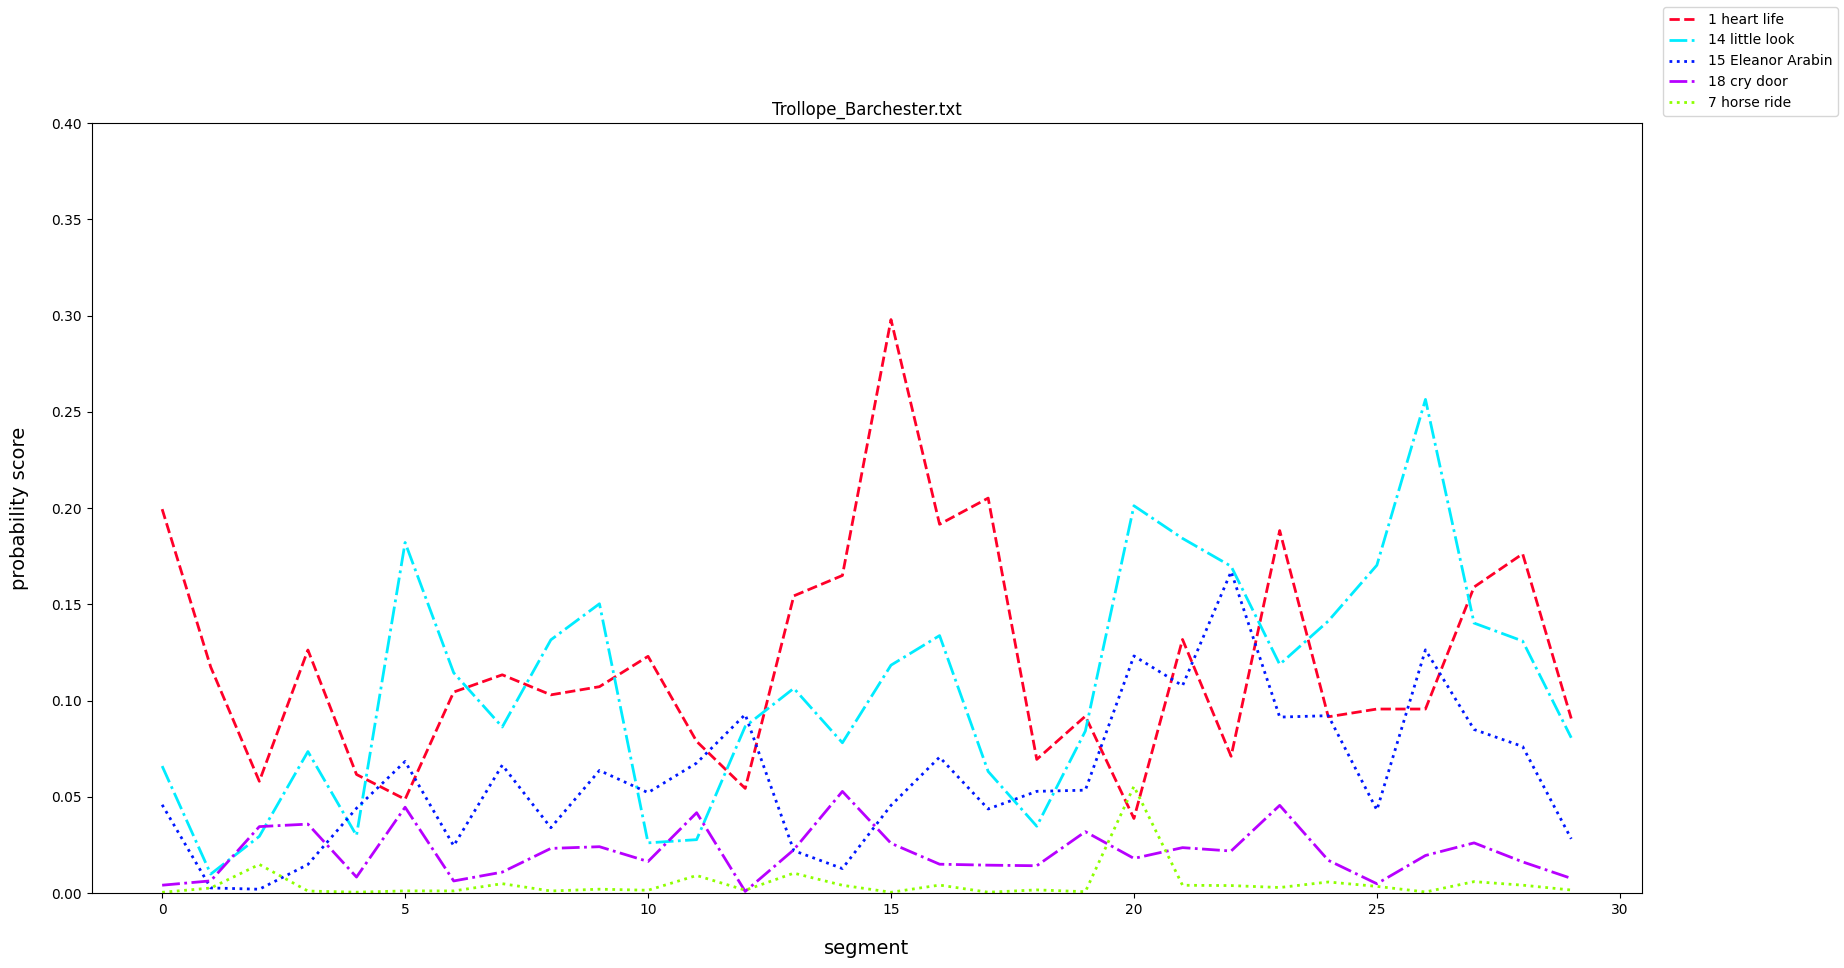

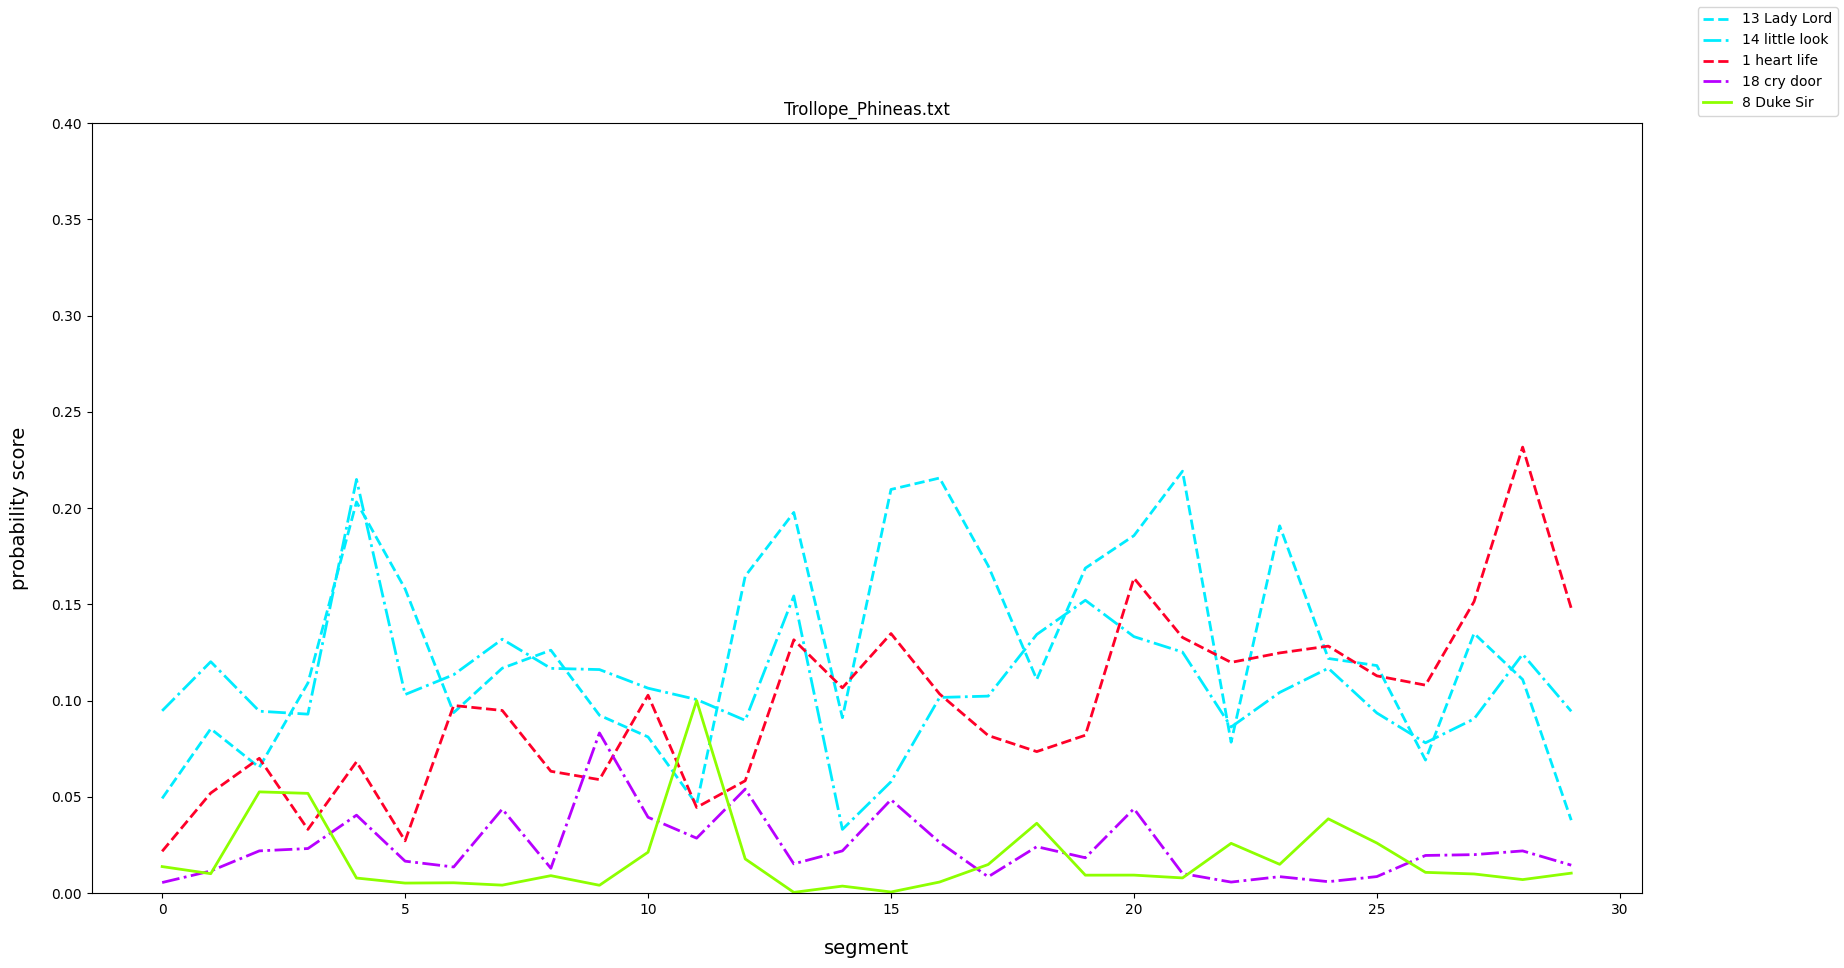

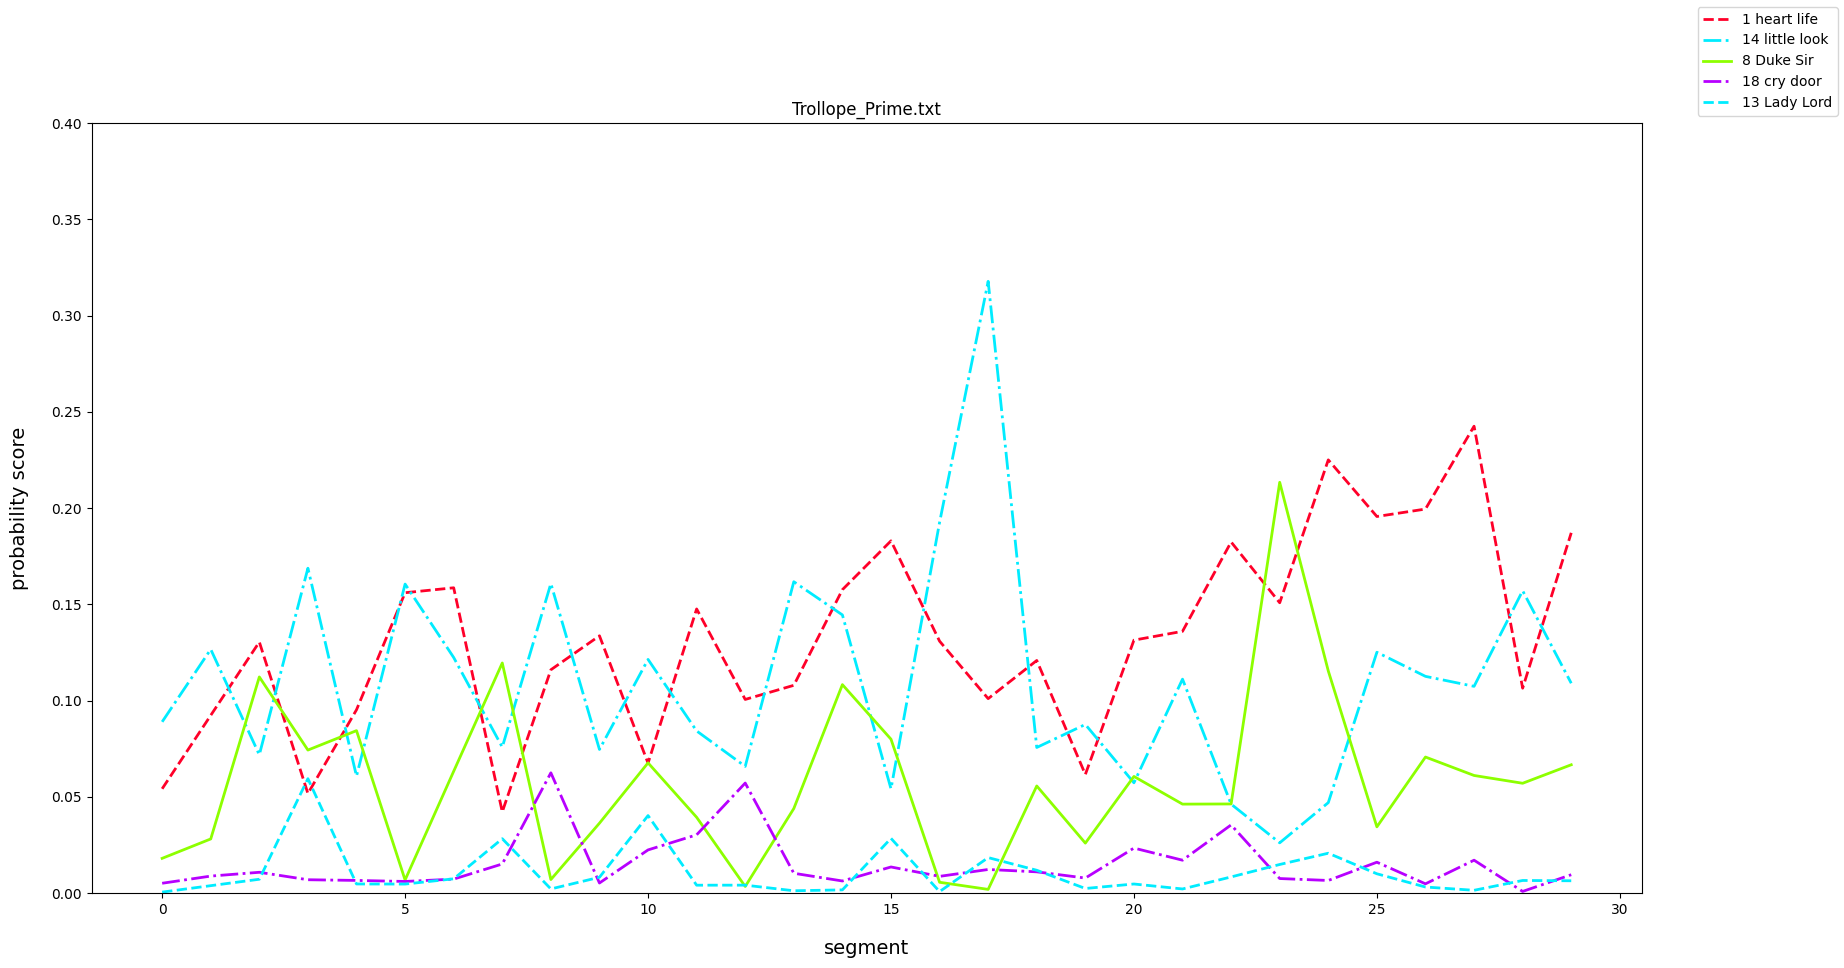

In [28]:
for textno in (range(0, len(dom_topics))):
    
    NUM_COLORS = 20
    NUM_STYLES=4
    LINE_STYLES = ['solid', 'dashed', 'dashdot', 'dotted']

    cm = plt.get_cmap('gist_rainbow')
    fig = plt.figure(figsize=(20,10))
    ax = fig.add_subplot(111)
    ax.set_ylim(0, 0.7)
    ax.set_title(labels[textno])
    ax.set_xlabel('segment', labelpad=16, fontsize=14)
    ax.set_ylabel('probability score', labelpad=16, fontsize=14)
    for i in dom_topics[textno]:
        lines = ax.plot(wyniki[textno][i])
        lines[0].set_color(cm(i//3*3.0/NUM_COLORS))
        lines[0].set_linewidth(2)
        lines[0].set_linestyle(LINE_STYLES[i%NUM_STYLES])
        
    #fig.legend(keywords3, loc='upper right')
    #fig.legend(range(0,20), loc='upper right')
    legend=[]
    for i in dom_topics[textno]:
        legend.append(str(i)+ ' '+' '.join(topicwords[i][:2])) #i-1: index starts with 0
    fig.legend(legend)
    #loc='upper left', shadow=True, ncol=1)
    #fig.savefig(labels[textno]+'.png')
    plt.show()

In [ ]:
#przeglądanie fragmentów tekstu

In [28]:
no_steps=30
chunks=[]

text=data_lemmatized[27]

step=int(len(text)/no_steps)
window_size=int(len(text)/(no_steps-1))

for counter in range(no_steps):
    chunk=[]
    chunk=text[counter*step:(counter*step+window_size)]
    chunks.append(chunk)

In [33]:
chunks[29]

['cicho',
 'tajemniczo',
 'głębić',
 'dochodzić',
 'wolno',
 'głos',
 'dzwon',
 'przysłuchiwać',
 'wraz',
 'wysoki',
 'człowiek',
 'raz',
 'drugi',
 'położyć',
 'palec',
 'usta',
 'rzec',
 'powtórnie',
 'chodzić',
 'chodzić',
 'północ',
 'zbliżać',
 'głos',
 'zmienić',
 'wciąż',
 'miejsce',
 'poruszać',
 'wówczas',
 'cicho',
 'uczynić',
 'nadsłuchiwać',
 'honorowy',
 'zwierzę',
 'orzeł',
 'wąż',
 'nadsłuchiwać',
 'jaskinia',
 'wielki',
 'chłodny',
 'księżyc',
 'noc',
 'zdać',
 'słuchać',
 'położyć',
 'raz',
 'trzeci',
 'palec',
 'usta',
 'rzec',
 'chodzić',
 'chodzić',
 'chodzić',
 'noc',
 'pobłądzić',
 'godzina',
 'społem',
 'noc',
 'lud',
 'wysoki',
 'północ',
 'zbliżać',
 'chcieć',
 'ucho',
 'rzec',
 'stary',
 'dzwon',
 'nieraz',
 'ucho',
 'szeptać',
 'tajemnie',
 'okrutnie',
 'serdecznie',
 'przemawiać',
 'północ',
 'dzwon',
 'przeżyć',
 'przeżywać',
 'człek',
 'mierzyć',
 'ojciec',
 'bolesny',
 'serce',
 'uderzenie',
 'wzdychać',
 'snąć',
 'śmiać',
 'stary',
 'głęboki',
 'głęboki'

In [8]:
for counter in range(len(labels)):
    print(counter, ', ', labels[counter])

0 ,  Berent_Fachowiec.txt
1 ,  Berent_Nurt.txt
2 ,  Berent_Ozimina.txt
3 ,  Berent_Prochno.txt
4 ,  Grabinski_Bledny pociag.txt
5 ,  Grabinski_Cien Bafometa.txt
6 ,  Grabinski_Salamandra.txt
7 ,  Lange_Elfryda - Nowele i fantazje.txt
8 ,  Lange_Nowy Tarzan - Opowiadania wesole i niewesole.txt
9 ,  Lange_W czwartym wymiarze - opowiadania.txt
10 ,  Lesmian_Klechdy polskie.txt
11 ,  Lesmian_Klechdy sezamowe.txt
12 ,  Lesmian_Przygody Sindbada Zeglarza.txt
13 ,  Licinski_Halucynacje.txt
14 ,  Licinski_Z pamietnika wloczegi.txt
15 ,  Micinski_Nietota.txt
16 ,  Micinski_Xiadz Faust.txt
17 ,  Mirandola_Tempore belli.txt
18 ,  Mirandola_Tropy.txt
19 ,  Nietzsche_Antychryst_Staff.txt
20 ,  Nietzsche_Dytyramby dionizyjskie.txt
21 ,  Nietzsche_Ecce homo_Staff.txt
22 ,  Nietzsche_Jutrzenka_Wyrzykowski.txt
23 ,  Nietzsche_Ludzkie, arcyludzkie t. 1_Drzewiecki.txt
24 ,  Nietzsche_Narodziny tragedii_Staff.txt
25 ,  Nietzsche_Niewczesne rozważania_Staff.txt
26 ,  Nietzsche_Poza dobrem i złem_Wyrzykowsk